# <b>Deep Learning Group Project – Sentiment Classification of Movie Reviews (IMDB dataset)

---
<font face="Courier New" size="4" color="blue">
<b>Students:</b>&nbsp;D00225328 Jubilee Osowa<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;D00285904 Guilherme Sonego Neto<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;D00285895 George Semain<br>
</font>

---
<b>Programme:</b> PGDip Applied Data Science<br>
<b>Module:</b> SWRDC9011 Machine Learning and AI with Industrial Applications<br>
<b>Lecturer:</b> Dr. Sargam Yadav<br>
<b>Date:</b> April 2026<br>

---

## Step 0 – Problem Identification

### Real-world problems suitable for applying machine learning and deep learning models

A project kick-off meeting, attended by all three students, considered the Project Brief and performed a non-exhaustive research of various real-world text and image problems that could be alternatives for implementation:

*   Positive or Negative classification of the sentiment of user movie reviews
*   Detection of fake news articles
*   Classifying received e-mails as spam or legitimate
*   Categorising news articles
*   Classification of helpdesk support tickets
*   Product review star-rating prediction
*   Image classification of handwritten digits (the MNIST standard dataset)
*   Medical image classification (presence/absence of a disease)
*   Object recognition within images (such as classification of dog breeds)
*   Detection of language of a piece of text

These alternatives span both Natural Language Processing and Computer Vision domains and demonstrate real-world applications across industry sectors such as media, healthcare, customer service, information security.

The discussion showed that there are many possible text-based and image-based problems that could be addressed using machine learning.

Both text and image related problems were considered, and it was agreed by the group to use a text-based problem on the basis that transformer-based language models (such as BERT) are very good at natural language processing, and it was considered that text-based data was likely to be more readily available than suitable image datasets, and would require less pre-processing than image datasets.

We agreed to implement a binary sentiment classification (positive or negative) of user movie reviews.

## Step 1 – Problem Understanding


The <i>Internet Movie Database</i>, known as IMDb, was founded in 1990 and is an online information platform for films, TV programmes, gaming and streaming content. The URL is www.imdb.com.

One of the key features of the platform enables users to rate movies and to post reviews. The user ratings are given as a score between 1 (poor) and 10 (excellent) for each movie. User ratings are used by the platform's algorithm to generate an aggregated score for each movie. User reviews are generally a guide to potential viewers and help determine if they should watch the movies. Both reviews and ratings are used by the platform to influence a movie's overall score.

A <i>review</i> is a text-based comment attributed to a movie, posted by a registered user of the platform. The 'sentiment' of a review is a binary classification of whether the review is <i>positive</i> or <i>negative</i>. In addition to quantitative <i>ratings</i>, it is the sentiment of user reviews that influence how a movie is scored.

It is therefore necessary for the platform to be able to determine a binary classification (positive or negative) of the sentiment of a user review.

The objective of this project is to train and compare three models for sentiment classification and evaluate their performance.

### Proposed Solution


In particular, the project will 'solve' the problem by implementing and comparing three types of models:
* a traditional machine learning <b>Logistic Regression model</b> with TF-IDF
* a standard deep learning <b>LSTM model</b>
* a transformer-based deep learning <b>BERT model</b>

### Implementation Approach


The second project meeting, attended by all three students, agreed the problem statement and proposed solution.<br>
The following implementation approach was agreed

1.   Select a real-world problem to apply machine learning and deep learning techniques
2.   Identify a suitable dataset and load it
3.   Perform exploratory data analysis to understand the data
4.   Process the data so that it can be used by models
5.   Build (train and test) the three models
6.   Compare the models' performance
7.   Explain key learnings and potential future work


### Team Work

It was agreed that each student would implement a different model
* George -> Logistic Regression with TF-IDF
* Guilherme -> LSTM model
* Jubilee -> BERT model

All other stages of the project would be a collaboration by all three students working together.

It was agreed to use the Google Colab Notebook platform to enable all three students to work simultaneously on the same Python Notebook.

## Step 2 – Data Preparation


An internet search was conducted to identify available movie user review datasets of at least 10,000 samples, and labelled with positive or negative sentiment.

It was agreed to use the Hugging Face IMDb Movie Reviews Dataset which includes 50,000 movie reviews labelled as either positive or negative, which can be loaded by installing the Hugging Face <i>datasets</i> Python library, and loading the 'imdb' dataset.

The library documentation notes that a '0' value for the label represents a negative sentiment, and a '1' value for the label represents a positive sentiment. It also explains that the dataset comes pre-split into a training dataset and a testing dataset.

In [62]:
# it is necessary to install the 'datasets' library
#!pip install datasets

In [63]:
from datasets import load_dataset
import pandas as pd

In [64]:
dataset = load_dataset("imdb")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


This clearly shows that the dataset is structured like a dictionary, with a training set of 25,000 rows and a testing set of 25,000 rows.

However, one of the important steps in data preparation is to ensure that the data is balanced with equal proportions of positive and negative labels in both sets. This is important in classification models to prevent model bias in predicting one class more frequently than the other.

Rather than assume this is the case, before using the pre-split data, it is important to check the data is balanced.

In [65]:
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

print("Distribution of the Training Set")
print(df_train["label"].value_counts())

print("\nDistribution of the Test Set")
print(df_test["label"].value_counts())

Distribution of the Training Set
label
0    12500
1    12500
Name: count, dtype: int64

Distribution of the Test Set
label
0    12500
1    12500
Name: count, dtype: int64


This is excellent, as it confirms there is an equal number of positive and negative sentiment reviews in each dataset (12,500 of each in each dataset).

This can be further evidenced through a simple visualisation.

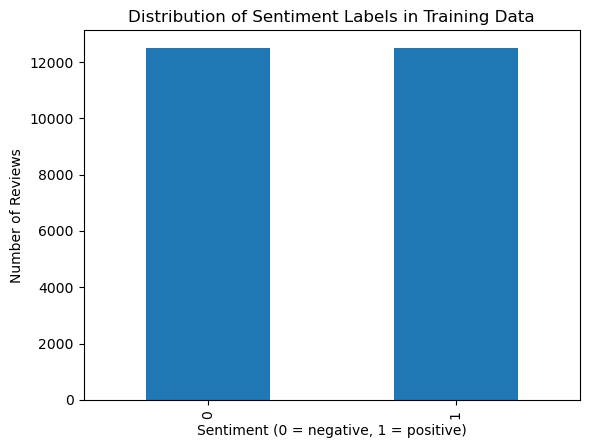

In [66]:
import matplotlib.pyplot as plt

df_train["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Sentiment Labels in Training Data")
plt.xlabel("Sentiment (0 = negative, 1 = positive)")
plt.ylabel("Number of Reviews")

plt.show()

To assist with data exploration, the data was loaded to a Pandas dataframe.

In [67]:
df_train = pd.DataFrame(dataset["train"])
df_train.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [68]:
df_test = pd.DataFrame(dataset["test"])
df_test.head()

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0


## Step 3 – Exploration of Data


### Examine the length (number of characters) of each user review

It is important to consider the length of the text of each review as models must be able to handle both short and long text. This is of relevance in LSTM and transformer models.

In [69]:
df_train["review_length"] = df_train["text"].str.len()
df_train["review_length"].describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64

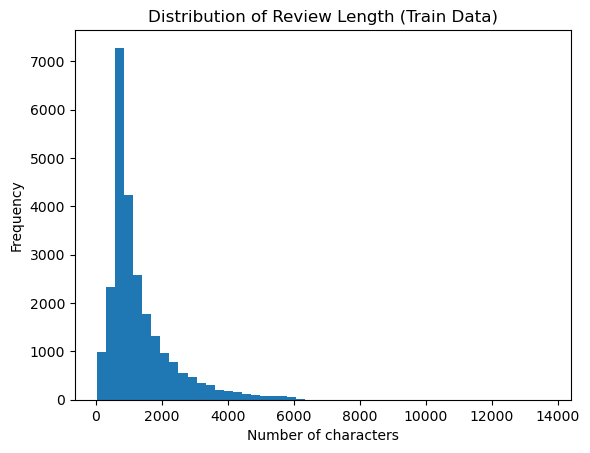

In [70]:
plt.hist(df_train["review_length"], bins=50)
plt.title("Distribution of Review Length (Train Data)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")

plt.show()

This is clearly a right-skewed distribution, showing a long tail extending to the right, and most observations on the low side (left).

In [71]:
df_test["review_length"] = df_test["text"].str.len()
df_test["review_length"].describe()

count    25000.00000
mean      1293.79240
std        975.90776
min         32.00000
25%        696.00000
50%        962.00000
75%       1572.00000
max      12988.00000
Name: review_length, dtype: float64

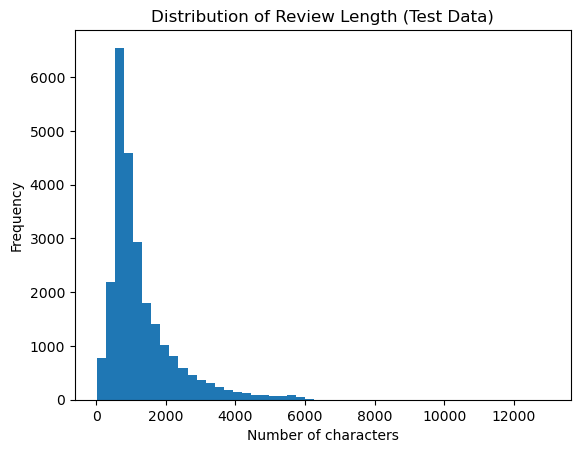

In [72]:
plt.hist(df_test["review_length"], bins=50)
plt.title("Distribution of Review Length (Test Data)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")

plt.show()

This is also clearly a right-skewed distribution.

Both histograms show that there is considerable variation in review lengths, and models will need to be able to process both short text and long text. As both follow a similar right-skewed distribution. This suggests that both the training and test datasets follow a similar distribution, which is desirable for modelling.

In [73]:
df_train["review_length"].mean()

np.float64(1325.06964)

In [74]:
df_test["review_length"].mean()

np.float64(1293.7924)

The average review length for both the training data (1,325 characters) and testing data (1,293) is very similar. This represents a substantial length of text for sentiment analysis modeling.

### Show the proportion of positive and negative reviews

In [75]:
df_train["label"].value_counts(normalize=True)

label
0    0.5
1    0.5
Name: proportion, dtype: float64

There is an equal number of positive and negative reviews (balanced data labels).

### Show examples of positive and negative reviews

In [76]:
print("Example Positive Review:\n")
print(df_train[df_train["label"] == 1]["text"].iloc[0])

print("\n\nExample Negative Review:\n")
print(df_train[df_train["label"] == 0]["text"].iloc[0])

Example Positive Review:

Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is intentional: it is presented as a dream/nightmare, and making it too coherent would spoil the effect. <br /><br />This movie is unrelentingly grim--"noir" in more than one sense; one never sees the sun shine. Grim, but intriguing, and frightening.


Example Negative Review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter

To avoid having to scroll the output, this can be resolved by setting a text-wrap width.

In [77]:
import textwrap

print("Example Positive Review:\n")

print(textwrap.fill(
    df_train[df_train["label"] == 1]["text"].iloc[0],
    width=100
))

print("\n\nExample Negative Review:\n")

print(textwrap.fill(
    df_train[df_train["label"] == 0]["text"].iloc[0],
    width=100
))

Example Positive Review:

Zentropa has much in common with The Third Man, another noir-like film set among the rubble of
postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who
gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the
more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a
more well-crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is
intentional: it is presented as a dream/nightmare, and making it too coherent would spoil the
effect. <br /><br />This movie is unrelentingly grim--"noir" in more than one sense; one never sees
the sun shine. Grim, but intriguing, and frightening.


Example Negative Review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it
when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it
ever tried to enter

Reading the example reviews, it is possible to observe some markup language tags, such as ```<br /><br />```. These can be removed.

In [78]:
df_train["text"] = df_train["text"].str.replace("<br />", " ", regex=False)
df_test["text"] = df_test["text"].str.replace("<br />", " ", regex=False)

In [79]:
from IPython.display import Markdown, display
import textwrap

pos_review = textwrap.fill(
    df_train[df_train["label"] == 1]["text"].iloc[0],
    width=100
)

neg_review = textwrap.fill(
    df_train[df_train["label"] == 0]["text"].iloc[0],
    width=100
)

display(Markdown(f"### Example Positive Review\n\n{pos_review}"))
display(Markdown(f"### Example Negative Review\n\n{neg_review}"))

### Example Positive Review

Zentropa has much in common with The Third Man, another noir-like film set among the rubble of
postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who
gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the
more striking in contrast with the natives.  But I'd have to say that The Third Man has a more well-
crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is intentional: it is
presented as a dream/nightmare, and making it too coherent would spoil the effect.   This movie is
unrelentingly grim--"noir" in more than one sense; one never sees the sun shine. Grim, but
intriguing, and frightening.

### Example Negative Review

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it
when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it
ever tried to enter this country, therefore being a fan of films considered "controversial" I really
had to see this for myself.  The plot is centered around a young Swedish drama student named Lena
who wants to learn everything she can about life. In particular she wants to focus her attentions to
making some sort of documentary on what the average Swede thought about certain political issues
such as the Vietnam War and race issues in the United States. In between asking politicians and
ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher,
classmates, and married men.  What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was
considered pornographic. Really, the sex and nudity scenes are few and far between, even then it's
not shot like some cheaply made porno. While my countrymen mind find it shocking, in reality sex and
nudity are a major staple in Swedish cinema. Even Ingmar Bergman, arguably their answer to good old
boy John Ford, had sex scenes in his films.  I do commend the filmmakers for the fact that any sex
shown in the film is shown for artistic purposes rather than just to shock people and make money to
be shown in pornographic theaters in America. I AM CURIOUS-YELLOW is a good film for anyone wanting
to study the meat and potatoes (no pun intended) of Swedish cinema. But really, this film doesn't
have much of a plot.

### Explore Relationship of Review Length and Label Value

We explore whether review length has any relationship with sentiment. For example, a negative review could potentially be longer if the user provided longer explanation to justify how they were dissatisfied, whereas positive reviews could be more concise, on  the basis the user may not feel it necessary to go into detail why they liked it.

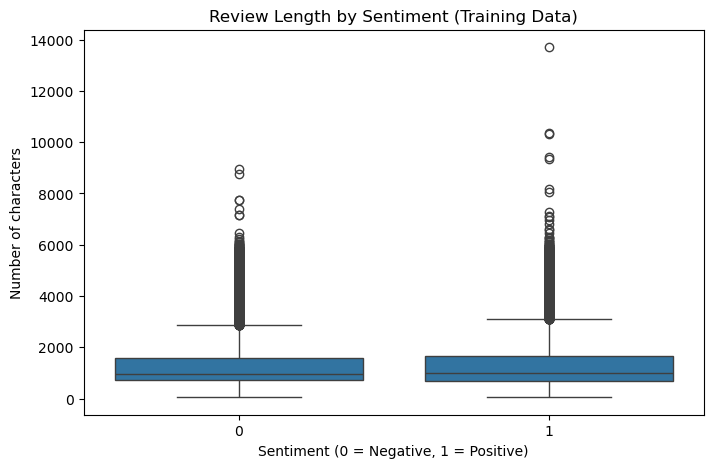

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="review_length",
    data=df_train
)

plt.title("Review Length by Sentiment (Training Data)")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Number of characters")

plt.show()

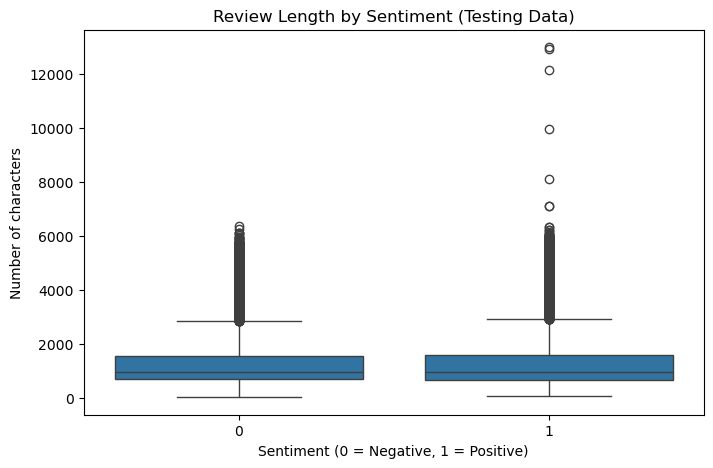

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="review_length",
    data=df_test
)

plt.title("Review Length by Sentiment (Testing Data)")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Number of characters")

plt.show()

In [82]:
df_train.groupby("label")["review_length"].mean()

label
0    1302.97904
1    1347.16024
Name: review_length, dtype: float64

In [83]:
df_test.groupby("label")["review_length"].mean()

label
0    1285.14968
1    1302.43512
Name: review_length, dtype: float64

The difference in average review length between positive and negative sentiment is small, suggesting that review length alone is not a strong predictor of sentiment. The mean review lengths are slightly lower in  testing dataset than the training dataset, although the same order of magnitude.

## Step 4 – Feature Engineering & Representation


Models cannot work directly with raw text, so it must first be converted into numerical form.

Different types of models require different forms of representation. This is the case for the models we have selected:

*   **Logistic Regression** requires numerical feature vectors. In general, it isn't sophisticated to understand word order.
*   **LSTM** requires tokenised and padded sequences. It is better than logistic regression at understanding word order.
*   **BERT** requires specialised transformer tokenisation. It is better than Logistic Regression and LSTM in understanding word meaning and context

On this basis, different representation techniques have to be applied for each model.

### 4.1 TF-IDF Representation (for Logistic Regression)

Traditional machine learning models such as logistic regression cannot work directly from raw text (computer processors understand numbers, not text), hence it is necessary to convert the text into numerical representations of the text (vectors) that enable patterns within the text to be represented.

<b>Term Frequency (TF)</b> is a technique that counts how many times a particular word is found in the text (in this case a user review). Hence words that appear more frequently have a higher value. Small words (for example, of, the, in, at, ...) are insignificant to the meaning of the review but can appear frequently - hence these 'stopwords' are excluded from the representation.<br><br>
<b>Inverse Document Frequency (IDF)</b> is another technique that looks across all of the text (all reviews) to determine how rare a word is. Words that do not appear very often can have more significance and meaning than words that appear very frequently, hence IDF gives a higher score for words  that do not appear frequently across all reviews.<br><br>
By taking the product TF * IDF, a word gets a high score when it appears frequently in a review and is not frequently used across all reviews. In this way, every word (the total vocabulary excluding stopwords) can be given a score for a particular review. Those numerical values per word form the vector representation for the review. This is the way that a review text (words) can be represented as a consistent numerical vector using <b>TF-IDF</b> encoding. Some words in the vocabulary will not appear in the review and will score zero in the vector. The higher the numerical representation for a word, the more important that word is considered to be.

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# create a validation set from the training data set only
# (keeping the test data set completely separate)
# use stratify to preserve a balanced data between training and validation sets
# use 20% of the test data set for validation
X_train_text_lg, X_val_text_lg, y_train_lg, y_val_lg = train_test_split(
    df_train["text"],
    df_train["label"],
    test_size=0.20,
    stratify=df_train["label"],
    random_state=42
)

# keep the official test set separate
X_test_text_lg = df_test["text"]
y_test_lg = df_test["label"]

# create TF-IDF vectorizer
# using the 10,000 most informative features
# ignore small insignificant stopwords
# include both single words (e.g. "excellent") and two-word combinations (e.g. "not good")
tfidf_vectorizer_lg = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

# fit on training data only, then transform validation and test data
X_train_tfidf_lg = tfidf_vectorizer_lg.fit_transform(X_train_text_lg)
X_val_tfidf_lg = tfidf_vectorizer_lg.transform(X_val_text_lg)
X_test_tfidf_lg = tfidf_vectorizer_lg.transform(X_test_text_lg)

print("TF-IDF training matrix shape:", X_train_tfidf_lg.shape)
print("TF-IDF validation matrix shape:", X_val_tfidf_lg.shape)
print("TF-IDF test matrix shape:", X_test_tfidf_lg.shape)

TF-IDF training matrix shape: (20000, 10000)
TF-IDF validation matrix shape: (5000, 10000)
TF-IDF test matrix shape: (25000, 10000)


The training data was further split into two subsets a) 80% training and b) 20% validation, and the balance of negative and positive sentiment labels was maintained using stratified sampling.

Numerical representation of the text using TF-IDF encoding was then fitted on the training text only, before transforming the validation and test text.

This produced numerical matrices to represent the significance/importance of words within each review. The Logistic Regression Model is able to use the matrices as input.

In [85]:
feature_names_lg = tfidf_vectorizer_lg.get_feature_names_out()
print("Number of TF-IDF features:", len(feature_names_lg))

Number of TF-IDF features: 10000


Each word in the vocabulary will have a score in every review (could be 0). By taking the average of all scores for a word (the average TF-IDF) and ranking them to see the words with the highest average TF-IDF score, these are the words that are relatively prominent across all of the text (corpus). High average TF-IDF score does not necessarily mean that the word is important in predicting sentiment. This is determined later through the model training when Logistic Regression determines a weighting (coefficient) for each word.<br><br>
A lot of reviews are going to contain words that appear frequently across all reviews (such as the word movie, or film, or actor). These aren't indicative of sentiment yet they could score high with TF-IDF.<br><br>


In [86]:
import numpy as np

mean_tfidf_lg = X_train_tfidf_lg.mean(axis=0).A1
top_indices_lg = np.argsort(mean_tfidf_lg)[-20:][::-1]

top_terms_lg = [(feature_names_lg[i], mean_tfidf_lg[i]) for i in top_indices_lg]
top_terms_lg[:10]

[('movie', np.float64(0.05011042925746513)),
 ('film', np.float64(0.04288274589323663)),
 ('like', np.float64(0.024332295299809348)),
 ('just', np.float64(0.022773614957977813)),
 ('good', np.float64(0.021427518771000117)),
 ('really', np.float64(0.018135905584584115)),
 ('story', np.float64(0.018069587806183035)),
 ('time', np.float64(0.018057345971949447)),
 ('bad', np.float64(0.01703741078491135)),
 ('great', np.float64(0.015600667636114994))]

These are words that are relatively frequent in reviews, not removed as stopwords, and moderately informative across many documents. But of course, a high TF-IDF on its own does not necessarily mean it has a significance to predict a specific sentiment. They are words important across the entire text (all reviews) - we need the model training to determine which words help predict sentiment (refer later section 5.1)

As two-word combinations can be important, it is interesting to check TF-IDF two-word combinations exists.

In [87]:
bigrams_lg = [f for f in feature_names_lg if " " in f]

print(bigrams_lg[:20])

['10 10', '10 lines', '10 minutes', '10 stars', '10 year', '10 years', '100 years', '12 year', '14 year', '15 minutes', '15 years', '19th century', '20 minutes', '20 years', '20th century', '21st century', '25 years', '30 minutes', '30 seconds', '30 years']


This confirms that two-word features have been represented in the vocabulary.

### 4.2 Tokenisation & sequence padding (for LSTM)

Unlike Logistic Regression with TF-IDF, the LSTM model cannot use raw text directly. The review text must first be converted into a numerical sequential representation.

For this purpose, the training reviews were tokenised using the Keras Tokenizer, which converts words into integer indices based on their frequency in the training corpus. The tokenizer was fitted only on the training data in order to avoid data leakage from the validation or test sets.

After tokenisation, each review became a sequence of integers of variable length. However, neural networks require inputs of consistent shape within each batch. Therefore, all sequences were padded to a fixed maximum length using post-padding. Reviews shorter than the maximum length were padded with zeros, while longer reviews were truncated.

For this initial LSTM model, a limited vocabulary size was used in order to keep the model computationally efficient and suitable for execution in Google Colab using CPU. A fixed maximum sequence length was also selected to balance information retention with training time.

#### Splitting blocks

In [88]:
# @title
from sklearn.model_selection import train_test_split

# Convert HuggingFace columns to standard Python lists
train_reviews_lstm = list(dataset["train"]["text"])
train_labels_lstm = list(dataset["train"]["label"])

test_texts_lstm = list(dataset["test"]["text"])
y_test_lstm = list(dataset["test"]["label"])

# Create validation split from training data
train_texts_lstm, val_texts_lstm, y_train_lstm, y_val_lstm = train_test_split(
    train_reviews_lstm,
    train_labels_lstm,
    test_size=0.2,
    random_state=42,
    stratify=train_labels_lstm
)

print("Training samples:", len(train_texts_lstm))
print("Validation samples:", len(val_texts_lstm))
print("Test samples:", len(test_texts_lstm))

Training samples: 20000
Validation samples: 5000
Test samples: 25000


#### Tokenizer / Padding

In [89]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Parameters for LSTM input representation
max_words_lstm = 10000
max_len_lstm = 200

# Fit tokenizer only on training texts
tokenizer_lstm = Tokenizer(num_words=max_words_lstm, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(train_texts_lstm)

# Convert text to integer sequences
X_train_seq_lstm = tokenizer_lstm.texts_to_sequences(train_texts_lstm)
X_val_seq_lstm = tokenizer_lstm.texts_to_sequences(val_texts_lstm)
X_test_seq_lstm = tokenizer_lstm.texts_to_sequences(test_texts_lstm)

# Pad sequences to fixed length
X_train_lstm = pad_sequences(X_train_seq_lstm, maxlen=max_len_lstm, padding="post", truncating="post")
X_val_lstm = pad_sequences(X_val_seq_lstm, maxlen=max_len_lstm, padding="post", truncating="post")
X_test_lstm = pad_sequences(X_test_seq_lstm, maxlen=max_len_lstm, padding="post", truncating="post")

# Convert labels to NumPy arrays
y_train_lstm = np.array(y_train_lstm)
y_val_lstm = np.array(y_val_lstm)
y_test_lstm = np.array(y_test_lstm)

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_val_lstm shape:", X_val_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)

print("y_train_lstm shape:", y_train_lstm.shape)
print("y_val_lstm shape:", y_val_lstm.shape)
print("y_test_lstm shape:", y_test_lstm.shape)

X_train_lstm shape: (20000, 200)
X_val_lstm shape: (5000, 200)
X_test_lstm shape: (25000, 200)
y_train_lstm shape: (20000,)
y_val_lstm shape: (5000,)
y_test_lstm shape: (25000,)


#### Vocabulary inspection

In [90]:
print("Vocabulary size learned by tokenizer:", len(tokenizer_lstm.word_index))
print("Maximum vocabulary used by model:", max_words_lstm)

Vocabulary size learned by tokenizer: 80220
Maximum vocabulary used by model: 10000


In [91]:
print("Original review:")
print(train_texts_lstm[0][:500])

print("\nTokenised sequence (first 30 tokens):")
print(X_train_seq_lstm[0][:30])

print("\nPadded sequence length:")
print(len(X_train_lstm[0]))

print("\nFirst 30 padded values:")
print(X_train_lstm[0][:30])

Original review:
I have always been a huge James Bond fanatic! I have seen almost all of the films except for Die Another Day, and The World Is Not Enough. The graphic's for Everything Or Nothing are breathtaking! The voice talents......... WOW! I LOVE PIERCE BROSNAN! He is finally Bond in a video game! HE IS BOND! I enjoyed the past Bond games: Goldeneye, The World Is Not Enough, Agent Under Fire, and Nightfire. This one is definitely the best! Finally, Mr. Brosnan, (may I call him Mr. Brosnan as a sign of resp

Tokenised sequence (first 30 tokens):
[11, 26, 210, 78, 4, 675, 574, 1552, 7151, 11, 26, 107, 222, 30, 5, 2, 106, 550, 16, 782, 156, 247, 3, 2, 183, 7, 22, 194, 2, 1]

Padded sequence length:
200

First 30 padded values:
[  11   26  210   78    4  675  574 1552 7151   11   26  107  222   30
    5    2  106  550   16  782  156  247    3    2  183    7   22  194
    2    1]


The tokenisation process transformed each review into a sequence of integers, where each integer corresponds to a word index in the learned vocabulary. The padded input matrices produced a consistent shape for all samples, which is required by the LSTM model.

The final representation used for the LSTM consisted of padded integer sequences with a maximum length of 200 tokens. The vocabulary was limited to the 10,000 most frequent words in the training data in order to reduce computational cost and make the model suitable for execution in Google Colab using CPU. This representation is appropriate for sequential deep learning models because it preserves word order while transforming the text into a fixed-size numerical input.

### 4.3 Transformer Tokenisation (for BERT)

For the transformer-based model, the text cannot be represented using TF-IDF vectors or simple integer sequences alone. Instead, a pretrained BERT tokenizer was used to convert each review into the format expected by the model.

The `bert-base-uncased` tokenizer was selected because it is a widely used pretrained English-language tokenizer and is well suited to sentiment classification tasks on movie reviews. Using a pretrained tokenizer ensures that the input representation is consistent with the pretrained BERT model used later in training.

Each review was tokenised into subword units rather than full words only. This helps the model handle rare words, unknown words, and variations in spelling more effectively than simple word-level tokenisation.

During tokenisation, BERT automatically adds special tokens:
- `[CLS]` at the beginning of the review, which is used by BERT as the main sequence representation for classification
- `[SEP]` at the end of the review, which marks the end of the input sequence

To ensure consistent input size, all reviews were tokenised using truncation and padding to a fixed maximum sequence length. Reviews longer than the selected limit were truncated, while shorter reviews were padded with zeros. In addition to token IDs, attention masks were created so that the model can distinguish real tokens from padding tokens.

To keep the methodology correct, the original IMDb training split was further divided into a BERT training subset and a validation subset. The official IMDb test split was kept untouched and reserved only for final evaluation. This avoids using the test set during model development.

The tokenised outputs were converted into PyTorch tensors and then organised into `TensorDataset` and `DataLoader` objects. These loaders are used later during BERT model training and evaluation.

In [92]:
# =========================
# 4.3 Transformer Tokenisation (for BERT)
# =========================

# Install transformers if needed
#!pip install -q transformers

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

df_train_full_bert = pd.DataFrame(dataset["train"])
df_test_bert = pd.DataFrame(dataset["test"])

print("Full training set shape:", df_train_full_bert.shape)
print("Official test set shape:", df_test_bert.shape)

# -------------------------
# 2. Split original training set into train + validation
#    Keep official test set untouched
# -------------------------
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    df_train_full_bert["text"],
    df_train_full_bert["label"],
    test_size=0.2,
    random_state=42,
    stratify=df_train_full_bert["label"]
)

X_test_bert = df_test_bert["text"]
y_test_bert = df_test_bert["label"]

print("BERT training samples:", len(X_train_bert))
print("BERT validation samples:", len(X_val_bert))
print("BERT test samples:", len(X_test_bert))

# -------------------------
# 3. Define pretrained tokenizer
# -------------------------
model_name_bert = "bert-base-uncased"
tokenizer_bert = BertTokenizer.from_pretrained(model_name_bert)

# -------------------------
# 4. Set sequence length
#    256 is a practical compromise for IMDb reviews
# -------------------------
max_len_bert = 256

# -------------------------
# 5. Tokenise text
# -------------------------
encoded_data_train_bert = tokenizer_bert(
    X_train_bert.tolist(),
    add_special_tokens=True,
    max_length=max_len_bert,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_tensors="pt"
)

encoded_data_val_bert = tokenizer_bert(
    X_val_bert.tolist(),
    add_special_tokens=True,
    max_length=max_len_bert,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_tensors="pt"
)

encoded_data_test_bert = tokenizer_bert(
    X_test_bert.tolist(),
    add_special_tokens=True,
    max_length=max_len_bert,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_tensors="pt"
)

# -------------------------
# 6. Extract tensors
# -------------------------
input_ids_train_bert = encoded_data_train_bert["input_ids"]
attention_masks_train_bert = encoded_data_train_bert["attention_mask"]
labels_train_bert = torch.tensor(y_train_bert.tolist())

input_ids_val_bert = encoded_data_val_bert["input_ids"]
attention_masks_val_bert = encoded_data_val_bert["attention_mask"]
labels_val_bert = torch.tensor(y_val_bert.tolist())

input_ids_test_bert = encoded_data_test_bert["input_ids"]
attention_masks_test_bert = encoded_data_test_bert["attention_mask"]
labels_test_bert = torch.tensor(y_test_bert.tolist())

print("Training input_ids shape:", input_ids_train_bert.shape)
print("Validation input_ids shape:", input_ids_val_bert.shape)
print("Test input_ids shape:", input_ids_test_bert.shape)

# -------------------------
# 7. Create TensorDatasets
# -------------------------
dataset_train_bert = TensorDataset(
    input_ids_train_bert,
    attention_masks_train_bert,
    labels_train_bert
)

dataset_val_bert = TensorDataset(
    input_ids_val_bert,
    attention_masks_val_bert,
    labels_val_bert
)

dataset_test_bert = TensorDataset(
    input_ids_test_bert,
    attention_masks_test_bert,
    labels_test_bert
)

# -------------------------
# 8. Create DataLoaders
# -------------------------
batch_size_bert = 16

dataloader_train_bert = DataLoader(
    dataset_train_bert,
    sampler=RandomSampler(dataset_train_bert),
    batch_size=batch_size_bert
)

dataloader_val_bert = DataLoader(
    dataset_val_bert,
    sampler=SequentialSampler(dataset_val_bert),
    batch_size=batch_size_bert
)

dataloader_test_bert = DataLoader(
    dataset_test_bert,
    sampler=SequentialSampler(dataset_test_bert),
    batch_size=batch_size_bert
)

print("Number of BERT training batches:", len(dataloader_train_bert))
print("Number of BERT validation batches:", len(dataloader_val_bert))
print("Number of BERT test batches:", len(dataloader_test_bert))

Full training set shape: (25000, 2)
Official test set shape: (25000, 2)
BERT training samples: 20000
BERT validation samples: 5000
BERT test samples: 25000
Training input_ids shape: torch.Size([20000, 256])
Validation input_ids shape: torch.Size([5000, 256])
Test input_ids shape: torch.Size([25000, 256])
Number of BERT training batches: 1250
Number of BERT validation batches: 313
Number of BERT test batches: 1563


#### Tokenization Inspection

In [93]:
# Inspect one tokenised example
sample_index_bert = 0

print("Original review:")
print(X_train_bert.iloc[sample_index_bert][:500])

print("\nToken IDs:")
print(input_ids_train_bert[sample_index_bert][:40])

print("\nAttention mask:")
print(attention_masks_train_bert[sample_index_bert][:40])

print("\nDecoded tokens:")
print(tokenizer_bert.convert_ids_to_tokens(input_ids_train_bert[sample_index_bert][:40]))

Original review:
I have always been a huge James Bond fanatic! I have seen almost all of the films except for Die Another Day, and The World Is Not Enough. The graphic's for Everything Or Nothing are breathtaking! The voice talents......... WOW! I LOVE PIERCE BROSNAN! He is finally Bond in a video game! HE IS BOND! I enjoyed the past Bond games: Goldeneye, The World Is Not Enough, Agent Under Fire, and Nightfire. This one is definitely the best! Finally, Mr. Brosnan, (may I call him Mr. Brosnan as a sign of resp

Token IDs:
tensor([  101,  1045,  2031,  2467,  2042,  1037,  4121,  2508,  5416,  5470,
        12070,   999,  1045,  2031,  2464,  2471,  2035,  1997,  1996,  3152,
         3272,  2005,  3280,  2178,  2154,  1010,  1998,  1996,  2088,  2003,
         2025,  2438,  1012,  1996,  8425,  1005,  1055,  2005,  2673,  2030])

Attention mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

De

The tokenisation output confirms that the reviews were successfully converted into fixed-length BERT inputs. Each instance now contains:
- token IDs representing the review text
- an attention mask identifying real tokens and padded positions
- the corresponding sentiment label

This representation is suitable for transformer-based model training because it preserves the token structure expected by the pretrained BERT architecture. The use of a separate validation split also ensures that model tuning can be performed without using the official test set.


The tokenisation results confirm that the BERT preprocessing pipeline was implemented correctly. The original IMDb training split was divided into a training subset of 20,000 reviews and a validation subset of 5,000 reviews, while the official test set of 25,000 reviews was kept untouched for final evaluation.

After tokenisation, each review was converted into a fixed-length sequence of 256 tokens. The outputs also show that the tokenizer added the special `[CLS]` token at the beginning of the sequence and produced attention masks to distinguish real tokens from padded positions.

The decoded example further confirms that BERT uses subword tokenisation. For example, the word `fanatic` was split into `fan` and `##atic`, showing how the tokenizer can represent words that may not appear as a single full token in the vocabulary.

These tokenised tensors and DataLoaders provide the correct input format for BERT model training in the next stage.

## Step 5 – Model Development

Three models are developed in this step: Logistic Regression, LSTM, and BERT. For each model, a baseline is first trained and evaluated on both the validation set and the held-out test set using default or minimal hyperparameters, establishing a reference performance level. Each model is then tuned across three further runs, with specific hyperparameters adjusted in each run based on analysis of baseline behaviour.

To systematically track and compare results across all runs, a shared results store is initialised below. Helper functions allow each run to log its hyperparameters and evaluation metrics into a structured dictionary, which can then be converted to a DataFrame for side-by-side comparison of all tuning configurations.

In [94]:
import pandas as pd

# Shared containers for all tuning runs (baseline + tuned).
tuning_results = {
    "logistic_regression": [],
    "lstm": [],
    "bert": []
}

def add_tuning_result(model_name, tuning_id, hyperparameters, metrics, notes=""):
    tuning_results[model_name].append({
        "model": model_name,
        "tuning_id": tuning_id,
        "hyperparameters": hyperparameters,
        "validation_accuracy": metrics.get("validation_accuracy"),
        "test_accuracy": metrics.get("test_accuracy"),
        "precision": metrics.get("precision"),
        "recall": metrics.get("recall"),
        "f1": metrics.get("f1"),
        "notes": notes
    })

def get_model_tuning_results_df(model_name):
    rows = tuning_results.get(model_name, [])
    return pd.DataFrame(rows)

def get_all_tuning_results_df():
    rows = []
    for model_rows in tuning_results.values():
        rows.extend(model_rows)
    return pd.DataFrame(rows)

print("Tuning results scaffolding ready.")

Tuning results scaffolding ready.


### 5.1 Logistic Regression (Baseline)

Logistic Regression is a technique that will determine a weighting value for each word (a coefficient) based on whether it is associated with a review labelled as 0 (negative sentiment) or a review labelled as 1 (positive sentiment). Words most associated with positive sentiment will have a greater positive weighting. Words most associated with negative sentiment will have a greater negative weighting.<br><br>
In this way, a new review can be  represented as a TF-IDF vector, which is then input to the trained Logistic Regression model which knows the weighting of certain words in relation to sentiment (based on its training), to score the sentiment of the text (with a positive coefficient or a negative coefficient).<br><br>
Logistic Regression takes the TF-IDF value for a word, multiplies it by the coefficient for that word (learned in training), giving what is called the 'contribution' score for that word. It does this for all words in the review. It then adds together all of  contribution scores. That weighted sum of feature contributions is passed through a logistic function to produce a probability between 0 and 1. If the probability is >0.5 then it is predicted to be a positive sentiment. If it is <0.5 then it is predicted to be a negative sentiment.

Although Logistic Regression is simpler than LSTM and BERT, it is useful as a performance benchmark against which other models can be assessed.

The model was trained on the TF-IDF representation of the reviews in the training dataset and then evaluated on both validation dataset and test dataset.

#### Logistic Regression Baseline Run

> Baseline hyperparameters used here: `max_iter=1000`, `random_state=42` (default solver and penalty).

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Logistic Regression - Baseline
lr_baseline_params = {
    "max_iter": 1000,
    "random_state": 42
}

lr_model_baseline = LogisticRegression(**lr_baseline_params)

# Train baseline model
lr_model_baseline.fit(X_train_tfidf_lg, y_train_lg)

# Validation predictions
y_val_pred_lg_baseline = lr_model_baseline.predict(X_val_tfidf_lg)

# Test predictions
y_test_pred_lg_baseline = lr_model_baseline.predict(X_test_tfidf_lg)

# Validation metrics
val_accuracy_lg_baseline = accuracy_score(y_val_lg, y_val_pred_lg_baseline)
val_precision_lg_baseline = precision_score(y_val_lg, y_val_pred_lg_baseline)
val_recall_lg_baseline = recall_score(y_val_lg, y_val_pred_lg_baseline)
val_f1_lg_baseline = f1_score(y_val_lg, y_val_pred_lg_baseline)

print("Baseline Validation Metrics")
print("Accuracy:", val_accuracy_lg_baseline)
print("Precision:", val_precision_lg_baseline)
print("Recall:", val_recall_lg_baseline)
print("F1-score:", val_f1_lg_baseline)

print("\nBaseline Validation Classification Report")
print(classification_report(y_val_lg, y_val_pred_lg_baseline))

# Test metrics
test_accuracy_lg_baseline = accuracy_score(y_test_lg, y_test_pred_lg_baseline)
test_precision_lg_baseline = precision_score(y_test_lg, y_test_pred_lg_baseline)
test_recall_lg_baseline = recall_score(y_test_lg, y_test_pred_lg_baseline)
test_f1_lg_baseline = f1_score(y_test_lg, y_test_pred_lg_baseline)

print("\nBaseline Test Metrics")
print("Accuracy:", test_accuracy_lg_baseline)
print("Precision:", test_precision_lg_baseline)
print("Recall:", test_recall_lg_baseline)
print("F1-score:", test_f1_lg_baseline)

print("\nBaseline Test Classification Report")
print(classification_report(y_test_lg, y_test_pred_lg_baseline))

# Keep one row per tuning_id if this cell is rerun
tuning_results["logistic_regression"] = [
    row for row in tuning_results["logistic_regression"]
    if row.get("tuning_id") != "LR_BASELINE"
 ]

add_tuning_result(
    model_name="logistic_regression",
    tuning_id="LR_BASELINE",
    hyperparameters=lr_baseline_params,
    metrics={
        "validation_accuracy": val_accuracy_lg_baseline,
        "test_accuracy": test_accuracy_lg_baseline,
        "precision": test_precision_lg_baseline,
        "recall": test_recall_lg_baseline,
        "f1": test_f1_lg_baseline
    },
    notes="Original baseline before tuning."
)

print("\nLogged LR_BASELINE into tuning_results.")

Baseline Validation Metrics
Accuracy: 0.8928
Precision: 0.882398753894081
Recall: 0.9064
F1-score: 0.8942383583267561

Baseline Validation Classification Report
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      2500
           1       0.88      0.91      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000


Baseline Test Metrics
Accuracy: 0.87936
Precision: 0.8753958201393287
Recall: 0.88464
F1-score: 0.8799936336145153

Baseline Test Classification Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


Logged LR_BASELINE into tuning_

#### Logistic Regression Tuning 1 Run

> Tuning 1 hyperparameters: `C=2.0`, `solver="liblinear"`, `penalty="l2"`, `max_iter=2000`, `random_state=42`.

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Logistic Regression - Tuning 1
lr_tuning_1_params = {
    "C": 2.0,
    "solver": "liblinear",
    "penalty": "l2",
    "max_iter": 2000,
    "random_state": 42
}

lr_model = LogisticRegression(**lr_tuning_1_params)

# train model
lr_model.fit(X_train_tfidf_lg, y_train_lg)

# validation predictions
y_val_pred_lg = lr_model.predict(X_val_tfidf_lg)

# test predictions
y_test_pred_lg = lr_model.predict(X_test_tfidf_lg)

# validation metrics
val_accuracy_lg = accuracy_score(y_val_lg, y_val_pred_lg)
val_precision_lg = precision_score(y_val_lg, y_val_pred_lg)
val_recall_lg = recall_score(y_val_lg, y_val_pred_lg)
val_f1_lg = f1_score(y_val_lg, y_val_pred_lg)

print("Validation Metrics")
print("Accuracy:", val_accuracy_lg)
print("Precision:", val_precision_lg)
print("Recall:", val_recall_lg)
print("F1-score:", val_f1_lg)

print("\nValidation Classification Report")
print(classification_report(y_val_lg, y_val_pred_lg))

# test metrics
test_accuracy_lg = accuracy_score(y_test_lg, y_test_pred_lg)
test_precision_lg = precision_score(y_test_lg, y_test_pred_lg)
test_recall_lg = recall_score(y_test_lg, y_test_pred_lg)
test_f1_lg = f1_score(y_test_lg, y_test_pred_lg)

print("\nTest Metrics")
print("Accuracy:", test_accuracy_lg)
print("Precision:", test_precision_lg)
print("Recall:", test_recall_lg)
print("F1-score:", test_f1_lg)

print("\nTest Classification Report")
print(classification_report(y_test_lg, y_test_pred_lg))

# Keep one row per tuning_id if this cell is rerun
tuning_results["logistic_regression"] = [
    row for row in tuning_results["logistic_regression"]
    if row.get("tuning_id") != "LR_TUNING_1"
]

add_tuning_result(
    model_name="logistic_regression",
    tuning_id="LR_TUNING_1",
    hyperparameters=lr_tuning_1_params,
    metrics={
        "validation_accuracy": val_accuracy_lg,
        "test_accuracy": test_accuracy_lg,
        "precision": test_precision_lg,
        "recall": test_recall_lg,
        "f1": test_f1_lg
    },
    notes="Tuning 1: higher C with liblinear to test weaker regularization on sparse TF-IDF features."
)

print("\nLogged LR_TUNING_1 into tuning_results.")

Validation Metrics
Accuracy: 0.8908
Precision: 0.881640625
Recall: 0.9028
F1-score: 0.892094861660079

Validation Classification Report
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      2500
           1       0.88      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000


Test Metrics
Accuracy: 0.87968
Precision: 0.8786500718046912
Recall: 0.88104
F1-score: 0.8798434129583766

Test Classification Report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


Logged LR_TUNING_1 into tuning_results.


#### Logistic Regression Tuning 2 Run

> Tuning 2 hyperparameters: `C=0.5`, `solver="liblinear"`, `penalty="l2"`, `max_iter=2000`, `random_state=42`.

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Logistic Regression - Tuning 2
lr_tuning_2_params = {
    "C": 0.5,
    "solver": "liblinear",
    "penalty": "l2",
    "max_iter": 2000,
    "random_state": 42
}

lr_model = LogisticRegression(**lr_tuning_2_params)

# train model
lr_model.fit(X_train_tfidf_lg, y_train_lg)

# validation predictions
y_val_pred_lg = lr_model.predict(X_val_tfidf_lg)

# test predictions
y_test_pred_lg = lr_model.predict(X_test_tfidf_lg)

# validation metrics
val_accuracy_lg = accuracy_score(y_val_lg, y_val_pred_lg)
val_precision_lg = precision_score(y_val_lg, y_val_pred_lg)
val_recall_lg = recall_score(y_val_lg, y_val_pred_lg)
val_f1_lg = f1_score(y_val_lg, y_val_pred_lg)

print("Validation Metrics")
print("Accuracy:", val_accuracy_lg)
print("Precision:", val_precision_lg)
print("Recall:", val_recall_lg)
print("F1-score:", val_f1_lg)

print("\nValidation Classification Report")
print(classification_report(y_val_lg, y_val_pred_lg))

# test metrics
test_accuracy_lg = accuracy_score(y_test_lg, y_test_pred_lg)
test_precision_lg = precision_score(y_test_lg, y_test_pred_lg)
test_recall_lg = recall_score(y_test_lg, y_test_pred_lg)
test_f1_lg = f1_score(y_test_lg, y_test_pred_lg)

print("\nTest Metrics")
print("Accuracy:", test_accuracy_lg)
print("Precision:", test_precision_lg)
print("Recall:", test_recall_lg)
print("F1-score:", test_f1_lg)

print("\nTest Classification Report")
print(classification_report(y_test_lg, y_test_pred_lg))

# Keep one row per tuning_id if this cell is rerun
tuning_results["logistic_regression"] = [
    row for row in tuning_results["logistic_regression"]
    if row.get("tuning_id") != "LR_TUNING_2"
 ]

add_tuning_result(
    model_name="logistic_regression",
    tuning_id="LR_TUNING_2",
    hyperparameters=lr_tuning_2_params,
    metrics={
        "validation_accuracy": val_accuracy_lg,
        "test_accuracy": test_accuracy_lg,
        "precision": test_precision_lg,
        "recall": test_recall_lg,
        "f1": test_f1_lg
    },
    notes="Tuning 2: stronger regularization than Tuning 1 to test generalization on sparse features."
)

print("\nLogged LR_TUNING_2 into tuning_results.")

Validation Metrics
Accuracy: 0.8868
Precision: 0.8716372021521906
Recall: 0.9072
F1-score: 0.8890631125049

Validation Classification Report
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      2500
           1       0.87      0.91      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000


Test Metrics
Accuracy: 0.8754
Precision: 0.8689362371255602
Recall: 0.88416
F1-score: 0.8764820175264681

Test Classification Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     12500
           1       0.87      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


Logged LR_TUNING_2 into tuning_results.


#### Logistic Regression Tuning 3 Run

> Tuning 3 hyperparameters: `C=1.25`, `solver="lbfgs"`, `penalty="l2"`, `max_iter=2000`, `random_state=42`.

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Logistic Regression - Tuning 3
lr_tuning_3_params = {
    "C": 1.25,
    "solver": "lbfgs",
    "penalty": "l2",
    "max_iter": 2000,
    "random_state": 42
}

lr_model = LogisticRegression(**lr_tuning_3_params)

# train model
lr_model.fit(X_train_tfidf_lg, y_train_lg)

# validation predictions
y_val_pred_lg = lr_model.predict(X_val_tfidf_lg)

# test predictions
y_test_pred_lg = lr_model.predict(X_test_tfidf_lg)

# validation metrics
val_accuracy_lg = accuracy_score(y_val_lg, y_val_pred_lg)
val_precision_lg = precision_score(y_val_lg, y_val_pred_lg)
val_recall_lg = recall_score(y_val_lg, y_val_pred_lg)
val_f1_lg = f1_score(y_val_lg, y_val_pred_lg)

print("Validation Metrics")
print("Accuracy:", val_accuracy_lg)
print("Precision:", val_precision_lg)
print("Recall:", val_recall_lg)
print("F1-score:", val_f1_lg)

print("\nValidation Classification Report")
print(classification_report(y_val_lg, y_val_pred_lg))

# test metrics
test_accuracy_lg = accuracy_score(y_test_lg, y_test_pred_lg)
test_precision_lg = precision_score(y_test_lg, y_test_pred_lg)
test_recall_lg = recall_score(y_test_lg, y_test_pred_lg)
test_f1_lg = f1_score(y_test_lg, y_test_pred_lg)

print("\nTest Metrics")
print("Accuracy:", test_accuracy_lg)
print("Precision:", test_precision_lg)
print("Recall:", test_recall_lg)
print("F1-score:", test_f1_lg)

print("\nTest Classification Report")
print(classification_report(y_test_lg, y_test_pred_lg))

# Keep one row per tuning_id if this cell is rerun
tuning_results["logistic_regression"] = [
    row for row in tuning_results["logistic_regression"]
    if row.get("tuning_id") != "LR_TUNING_3"
 ]

add_tuning_result(
    model_name="logistic_regression",
    tuning_id="LR_TUNING_3",
    hyperparameters=lr_tuning_3_params,
    metrics={
        "validation_accuracy": val_accuracy_lg,
        "test_accuracy": test_accuracy_lg,
        "precision": test_precision_lg,
        "recall": test_recall_lg,
        "f1": test_f1_lg
    },
    notes="Tuning 3: near-baseline setup with slight C increase to test a gentle regularization change.",
)

print("\nLogged LR_TUNING_3 into tuning_results.")

Validation Metrics
Accuracy: 0.8928
Precision: 0.8821011673151751
Recall: 0.9068
F1-score: 0.8942800788954635

Validation Classification Report
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      2500
           1       0.88      0.91      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000


Test Metrics
Accuracy: 0.87988
Precision: 0.8765363571485212
Recall: 0.88432
F1-score: 0.880410975269802

Test Classification Report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


Logged LR_TUNING_3 into tuning_results.


#### Logistic Regression Results

In [101]:
# Display all logistic regression tuning results
get_model_tuning_results_df("logistic_regression")

,model,tuning_id,hyperparameters,validation_accuracy,test_accuracy,precision,recall,f1,notes
0,logistic_regression,LR_BASELINE,"{'max_iter': 1000, 'random_state': 42}",0.8928,0.87936,0.875396,0.88464,0.879994,Original baseline before tuning.
1,logistic_regression,LR_TUNING_1,"{'C': 2.0, 'solver': 'liblinear', 'penalty': '...",0.8908,0.87968,0.878650,0.88104,0.879843,Tuning 1: higher C with liblinear to test weak...
2,logistic_regression,LR_TUNING_2,"{'C': 0.5, 'solver': 'liblinear', 'penalty': '...",0.8868,0.87540,0.868936,0.88416,0.876482,Tuning 2: stronger regularization than Tuning ...
3,logistic_regression,LR_TUNING_3,"{'C': 1.25, 'solver': 'lbfgs', 'penalty': 'l2'...",0.8928,0.87988,0.876536,0.88432,0.880411,Tuning 3: near-baseline setup with slight C in...


#### Final Evaluation of Logistic Regression Baseline and Tuning Runs

Four Logistic Regression configurations were evaluated: the baseline model and three tuning runs.

- **LR_BASELINE** (`max_iter=1000`, `random_state=42`) delivered strong balanced performance, with **validation accuracy = 0.8928**, **test accuracy = 0.87936**, **recall = 0.88464** (highest), and **F1-score = 0.87999**.
- **LR_TUNING_1** (`C=2.0`, `liblinear`) produced **validation accuracy = 0.8908**, **test accuracy = 0.87968**, and **F1-score = 0.87984**, slightly below the best run.
- **LR_TUNING_2** (`C=0.5`, `liblinear`) performed worst overall, with **validation accuracy = 0.8868**, **test accuracy = 0.87540**, and **F1-score = 0.87648**.
- **LR_TUNING_3** (`C=1.25`, `lbfgs`) produced the best overall test performance, with **test accuracy = 0.87988** (highest) and **F1-score = 0.88041** (highest), while matching the top validation accuracy (**0.8928**).

Based on this comparison, **LR_TUNING_3 is selected as the final Logistic Regression model** because it achieves the strongest overall generalisation on the test set.

#### Top predictive features for Logistic Regression

As Logistic Regression learns a coefficient for each TF-IDf feature, it is interesting to see which words are the features with the highest positive and negative coefficients as these are most useful at predicting sentiment.

In [ ]:
# get feature names and coefficients
#feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients_lg = lr_model.coef_[0]

# create dataframe for easier inspection
coef_df_lg = pd.DataFrame({
    "feature": feature_names_lg,
    "coefficient": coefficients_lg
})

# top positive and negative features
top_positive_lg = coef_df_lg.sort_values(by="coefficient", ascending=False).head(20)
top_negative_lg = coef_df_lg.sort_values(by="coefficient", ascending=True).head(20)

print("Top positive predictive words/phrases:")
print(top_positive_lg)

print("\nTop negative predictive words/phrases:")
print(top_negative_lg)


Top positive predictive words/phrases:
         feature  coefficient
3926       great     6.285002
2988   excellent     5.970723
902         best     5.348375
9851   wonderful     4.832942
6637     perfect     4.794058
433      amazing     4.235897
3191    favorite     4.035212
5377        love     3.687191
9111       today     3.647669
5387       loved     3.623942
1149   brilliant     3.391008
3638         fun     3.277992
2857       enjoy     3.123815
3650    funniest     3.102422
2212  definitely     3.101492
840    beautiful     3.062998
2864     enjoyed     3.015262
3          10 10     2.981504
8736      superb     2.980689
6641   perfectly     2.971099

Top negative predictive words/phrases:
             feature  coefficient
9893           worst    -8.259234
730              bad    -7.056040
705            awful    -6.283731
1076          boring    -5.554679
6840            poor    -5.315693
9667           waste    -5.269078
9891           worse    -4.869651
8923        terribl

This provides useful evidence that the model has learned meaningful relationship between specific words and sentiment labels.<br><br>
Additionally, the magnitude of the coefficients(+6.15 and -7.88) indicate strength to predict sentiment.<br><br>
Some features such as 'today' and 'script' are less obvious indicators of sentiment. Its possible they reflect dataset-specific patterns which highlights that the model has learned statistical associations as opposed to true semantic understanding, and hence may be indicative of a limitation of the model's predictive performance.

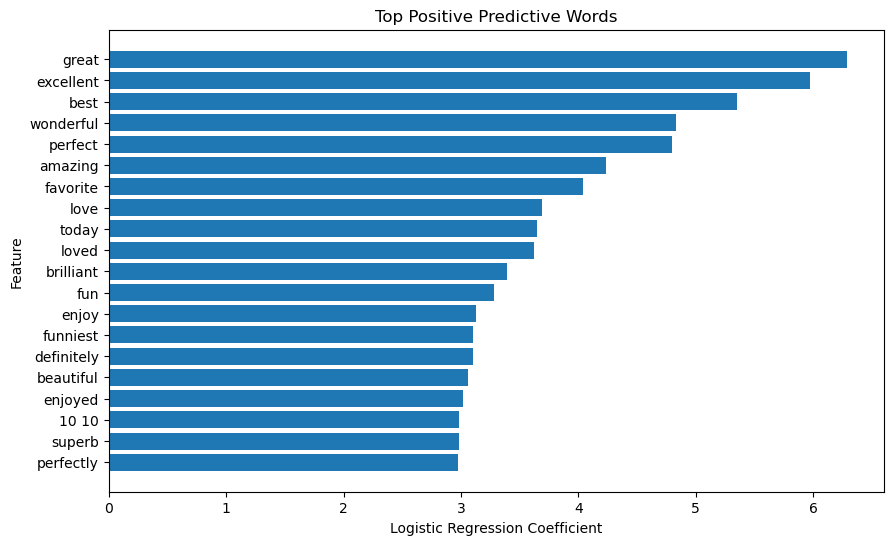

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_positive_lg["feature"][::-1], top_positive_lg["coefficient"][::-1])
plt.title("Top Positive Predictive Words")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

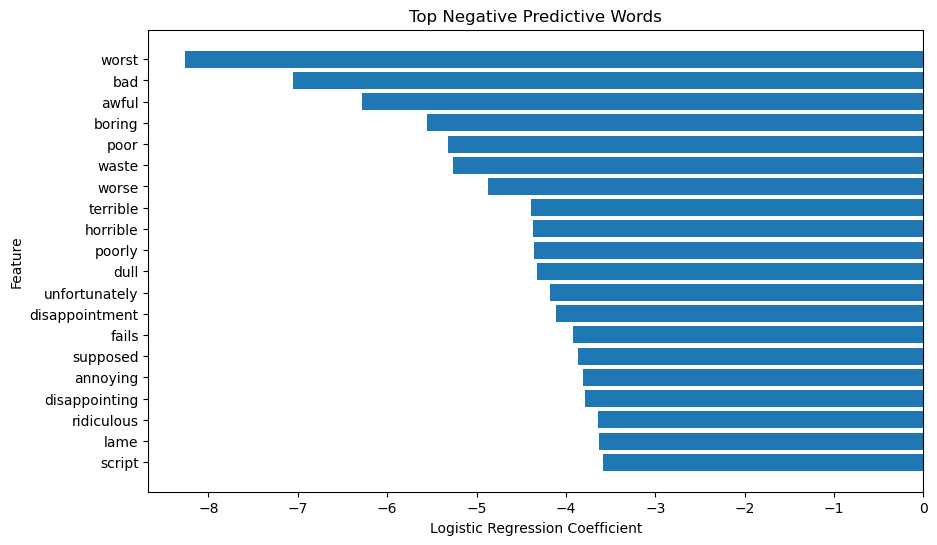

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_negative_lg["feature"][::-1], top_negative_lg["coefficient"][::-1])
plt.title("Top Negative Predictive Words")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

The visualisations provide a clear view of the variation in coefficient values.

#### Confusion Matrix

A Confusion Matrix helps to visualise how many negative reviews were correctly classified, how many positive reviews were correctly classified, and how many false positives and false negatives occurred.

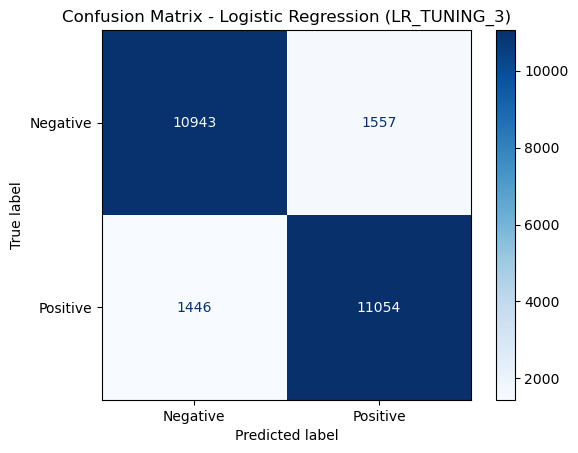

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use the selected best Logistic Regression configuration (LR_TUNING_3)
best_lr_model = LogisticRegression(**lr_tuning_3_params)
best_lr_model.fit(X_train_tfidf_lg, y_train_lg)
y_test_pred_lg_best = best_lr_model.predict(X_test_tfidf_lg)

ConfusionMatrixDisplay.from_predictions(
    y_test_lg,
    y_test_pred_lg_best,
    display_labels=["Negative", "Positive"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression (LR_TUNING_3)")
plt.show()

The heatmap clearly shows that a high proportion of both positive and negative reviews were correctly classified by the Logistic Regression model. The model makes a comparatively low number of classification errors.

#### Receiver Operating Characteristic (ROC) & Area Under the Curve (AUC)

The Receiver Operating Characteristic (ROC)  is a curve that evaluates model performance (predicting correctly positive & negative sentiment) across different probability thresholds. The plot is the True Positive Rate (Recall) against the Faslse Positive Rate.<br><br>

Additionally, the Area Under the Curve (AUC) provide a single metric of performance, with a score between 0 and 1, where 1 is perfect classification, and 0.5 being equivalent to a random guess.

ROC-AUC: 0.9507686719999999


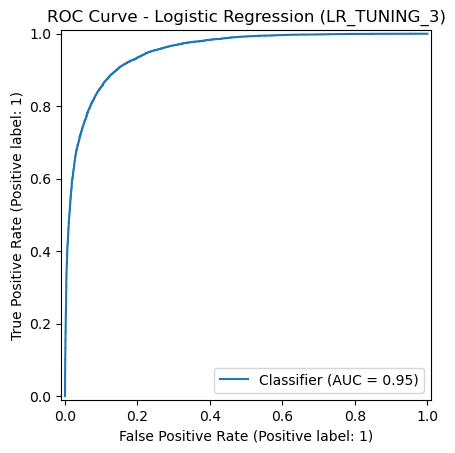

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Use the selected best Logistic Regression configuration (LR_TUNING_3)
best_lr_model = LogisticRegression(**lr_tuning_3_params)
best_lr_model.fit(X_train_tfidf_lg, y_train_lg)
y_test_prob_lg_best = best_lr_model.predict_proba(X_test_tfidf_lg)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test_lg, y_test_prob_lg_best))

RocCurveDisplay.from_predictions(y_test_lg, y_test_prob_lg_best)
plt.title("ROC Curve - Logistic Regression (LR_TUNING_3)")
plt.show()

This Logistic Regression model has an AUC of 0.95, which is very high performance in distinguishing between positive sentiment and negative sentiment.

### 5.2 LSTM Model

A Long Short-Term Memory (LSTM) network was selected as the standard deep learning model for this project. LSTM is a type of recurrent neural network designed to process sequential data and retain relevant information across time steps. This makes it suitable for text classification tasks, where the order of words contributes to meaning.

The model was designed using three main layers. First, an embedding layer was used to transform integer word indices into dense vector representations. Second, an LSTM layer was applied to learn sequential patterns within the reviews. Finally, a dense output layer with sigmoid activation was used to produce a binary sentiment prediction.

A simple architecture was chosen for the initial model in order to keep training time manageable in Google Colab using CPU, while still providing a meaningful comparison against the Logistic Regression and BERT models.

In [113]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input

lstm_model = Sequential([
    Input(shape=(max_len_lstm,)),
    Embedding(input_dim=max_words_lstm, output_dim=64),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

The model summary shows that the architecture is relatively compact, which is appropriate for this assignment context. The embedding layer learns dense word representations, while the LSTM layer captures sequential dependencies in the review text. The final sigmoid output supports binary classification of review sentiment.

The final LSTM architecture consisted of an embedding layer, a single LSTM layer, and a sigmoid output layer for binary classification. The model contained 673,089 trainable parameters, with most of the parameters located in the embedding layer. This is expected, as the embedding layer must learn a dense representation for each word in the selected vocabulary.

#### Training the LSTM model

The LSTM model was trained using the training dataset, with performance monitored on a validation set. A small number of epochs was selected to ensure that training remained computationally efficient while still allowing the model to learn meaningful patterns from the data.

A batch size of 32 was used, which is a standard choice for neural network training. Validation data was included during training in order to monitor model generalisation and detect potential overfitting.

In [114]:
import tensorflow as tf
import numpy as np
import random

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [115]:
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=3,
    batch_size=32,
    validation_data=(X_val_lstm, y_val_lstm)
)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 470s 750ms/step - accuracy: 0.5350 - loss: 0.6881 - val_accuracy: 0.5758 - val_loss: 0.6711
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 455s 728ms/step - accuracy: 0.5545 - loss: 0.6736 - val_accuracy: 0.5712 - val_loss: 0.6646
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 457s 731ms/step - accuracy: 0.5842 - loss: 0.6651 - val_accuracy: 0.5646 - val_loss: 0.6730


#### Model Evaluation

The LSTM baseline model showed variability across training experiments. Initial runs achieved approximately 0.66 test accuracy; however, the final logged result settled at a test accuracy of 0.55028 and F1-score of 0.41. This instability suggests the model was sensitive to random weight initialisation and training conditions without regularisation.

This indicates that the model did not perform as well as expected compared to the Logistic Regression baseline. In particular, the recall for positive sentiment was relatively low (0.47), meaning that a significant number of positive reviews were incorrectly classified as negative.

The relatively poor baseline performance is likely attributable to the limited number of training epochs (3), the simplicity of the architecture, and the absence of dropout or recurrent dropout. These factors contributed to overfitting in some runs and underfitting in others, as reflected by the declining validation accuracy across epochs. Hyperparameter tuning was subsequently applied to address these limitations.

Overall, the LSTM model demonstrates the ability to learn sequential patterns, but in this implementation it did not outperform the simpler baseline approach.

#### Training curves

Training and validation curves were plotted in order to examine the learning behaviour of the LSTM model across epochs. These curves provide a visual indication of whether the model is improving over time and whether there are any signs of underfitting or overfitting.

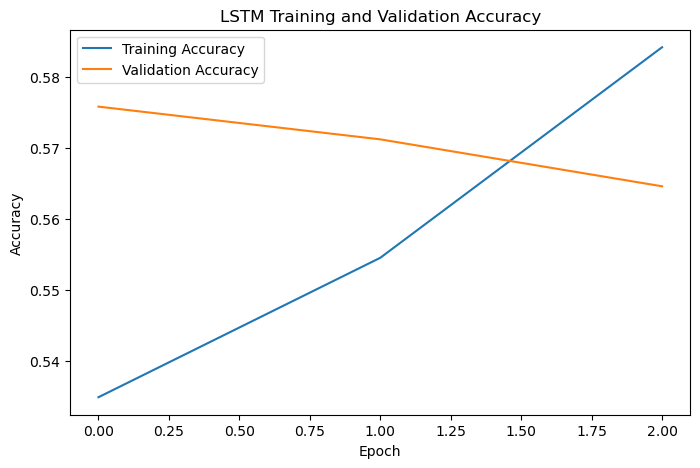

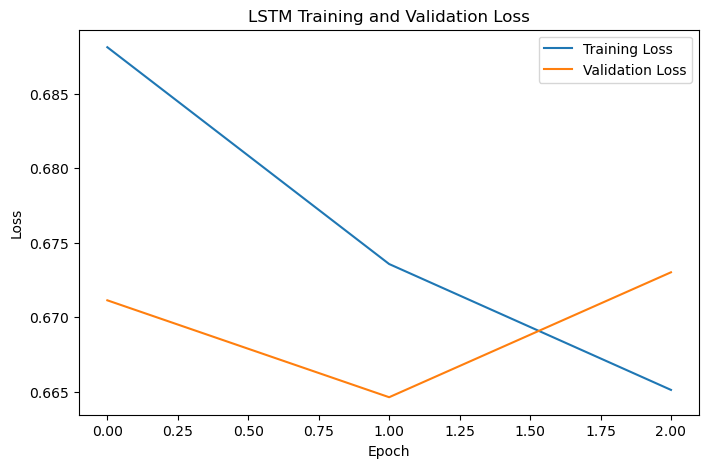

In [116]:
import matplotlib.pyplot as plt

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["accuracy"], label="Training Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The training curves show that accuracy improved during the early epochs. However, the validation accuracy does not continue improving in the final epoch, which suggests that the model may not have fully stabilised or may be starting to overfit.

Overall, the model shows some learning, but the behaviour indicates that further training or tuning would be required to achieve stronger performance.

#### Evaluation on the test dataset

After training, the LSTM model was evaluated on the unseen test dataset. Predictions were generated as probabilities and then converted into binary class labels using a threshold of 0.5.

Performance was assessed using accuracy, precision, recall, and F1-score, along with a confusion matrix to provide a detailed view of classification results.

In [117]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

# Predict probabilities (test)
y_pred_prob_lstm = lstm_model.predict(X_test_lstm)

# Convert to binary predictions (test)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int).flatten()

# Predict probabilities (validation)
y_val_pred_prob_lstm = lstm_model.predict(X_val_lstm)
y_val_pred_lstm = (y_val_pred_prob_lstm > 0.5).astype(int).flatten()

# Validation metrics
val_accuracy_lstm = accuracy_score(y_val_lstm, y_val_pred_lstm)
val_precision_lstm = precision_score(y_val_lstm, y_val_pred_lstm)
val_recall_lstm = recall_score(y_val_lstm, y_val_pred_lstm)
val_f1_lstm = f1_score(y_val_lstm, y_val_pred_lstm)

# Test metrics
accuracy_lstm = accuracy_score(y_test_lstm, y_pred_lstm)
precision_lstm = precision_score(y_test_lstm, y_pred_lstm)
recall_lstm = recall_score(y_test_lstm, y_pred_lstm)
f1_lstm = f1_score(y_test_lstm, y_pred_lstm)

print("Validation Accuracy:", val_accuracy_lstm)
print("Validation Precision:", val_precision_lstm)
print("Validation Recall:", val_recall_lstm)
print("Validation F1 Score:", val_f1_lstm)

print("\nTest Accuracy:", accuracy_lstm)
print("Precision:", precision_lstm)
print("Recall:", recall_lstm)
print("F1 Score:", f1_lstm)

print("\nClassification Report:\n")
print(classification_report(y_test_lstm, y_pred_lstm))

# Baseline hyperparameters used in the existing baseline architecture + training cell
lstm_baseline_params = {
    "embedding_dim": 64,
    "lstm_units": 64,
    "dropout": 0.0,
    "recurrent_dropout": 0.0,
    "epochs": 3,
    "batch_size": 32,
    "optimizer": "adam"
}

# Keep one row per tuning_id if this cell is rerun
tuning_results["lstm"] = [
    row for row in tuning_results["lstm"]
    if row.get("tuning_id") != "LSTM_BASELINE"
]

add_tuning_result(
    model_name="lstm",
    tuning_id="LSTM_BASELINE",
    hyperparameters=lstm_baseline_params,
    metrics={
        "validation_accuracy": val_accuracy_lstm,
        "test_accuracy": accuracy_lstm,
        "precision": precision_lstm,
        "recall": recall_lstm,
        "f1": f1_lstm
    },
    notes="Original LSTM baseline before tuning."
)

print("\nLogged LSTM_BASELINE into tuning_results.")

782/782 ━━━━━━━━━━━━━━━━━━━━ 205s 261ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 280ms/step
Validation Accuracy: 0.5646
Validation Precision: 0.6213373403456048
Validation Recall: 0.3308
Validation F1 Score: 0.4317410597755155

Test Accuracy: 0.55028
Precision: 0.597881949852048
Recall: 0.30712
F1 Score: 0.40579250568151787

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.79      0.64     12500
           1       0.60      0.31      0.41     12500

    accuracy                           0.55     25000
   macro avg       0.57      0.55      0.52     25000
weighted avg       0.57      0.55      0.52     25000


Logged LSTM_BASELINE into tuning_results.


#### LSTM Tuning 1 Run

Tuning 1 changes:
- Add dropout (`dropout=0.2`, `recurrent_dropout=0.2`) in the LSTM layer
- Increase training to 5 epochs
- Add early stopping to reduce overfitting risk

In [118]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import tensorflow as tf
import random

# Reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# LSTM - Tuning 1
lstm_tuning_1_params = {
    "embedding_dim": 64,
    "lstm_units": 64,
    "dropout": 0.2,
    "recurrent_dropout": 0.2,
    "epochs": 5,
    "batch_size": 32,
    "optimizer": "adam"
}

lstm_model_t1 = Sequential([
    Input(shape=(max_len_lstm,)),
    Embedding(input_dim=max_words_lstm, output_dim=lstm_tuning_1_params["embedding_dim"]),
    LSTM(
        lstm_tuning_1_params["lstm_units"],
        dropout=lstm_tuning_1_params["dropout"],
        recurrent_dropout=lstm_tuning_1_params["recurrent_dropout"]
    ),
    Dense(1, activation="sigmoid")
])

lstm_model_t1.compile(
    optimizer=lstm_tuning_1_params["optimizer"],
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_t1 = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
 )

history_lstm_t1 = lstm_model_t1.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=lstm_tuning_1_params["epochs"],
    batch_size=lstm_tuning_1_params["batch_size"],
    validation_data=(X_val_lstm, y_val_lstm),
    callbacks=[early_stopping_t1],
    verbose=1
)

# Validation predictions
y_val_pred_prob_lstm_t1 = lstm_model_t1.predict(X_val_lstm)
y_val_pred_lstm_t1 = (y_val_pred_prob_lstm_t1 > 0.5).astype(int).flatten()

# Test predictions
y_test_pred_prob_lstm_t1 = lstm_model_t1.predict(X_test_lstm)
y_test_pred_lstm_t1 = (y_test_pred_prob_lstm_t1 > 0.5).astype(int).flatten()

# Validation metrics
val_accuracy_lstm_t1 = accuracy_score(y_val_lstm, y_val_pred_lstm_t1)
val_precision_lstm_t1 = precision_score(y_val_lstm, y_val_pred_lstm_t1)
val_recall_lstm_t1 = recall_score(y_val_lstm, y_val_pred_lstm_t1)
val_f1_lstm_t1 = f1_score(y_val_lstm, y_val_pred_lstm_t1)

print("LSTM Tuning 1 - Validation Metrics")
print("Accuracy:", val_accuracy_lstm_t1)
print("Precision:", val_precision_lstm_t1)
print("Recall:", val_recall_lstm_t1)
print("F1-score:", val_f1_lstm_t1)

print("\nLSTM Tuning 1 - Validation Classification Report")
print(classification_report(y_val_lstm, y_val_pred_lstm_t1))

# Test metrics
test_accuracy_lstm_t1 = accuracy_score(y_test_lstm, y_test_pred_lstm_t1)
test_precision_lstm_t1 = precision_score(y_test_lstm, y_test_pred_lstm_t1)
test_recall_lstm_t1 = recall_score(y_test_lstm, y_test_pred_lstm_t1)
test_f1_lstm_t1 = f1_score(y_test_lstm, y_test_pred_lstm_t1)

print("\nLSTM Tuning 1 - Test Metrics")
print("Accuracy:", test_accuracy_lstm_t1)
print("Precision:", test_precision_lstm_t1)
print("Recall:", test_recall_lstm_t1)
print("F1-score:", test_f1_lstm_t1)

print("\nLSTM Tuning 1 - Test Classification Report")
print(classification_report(y_test_lstm, y_test_pred_lstm_t1))

# Keep one row per tuning_id if this cell is rerun
tuning_results["lstm"] = [
    row for row in tuning_results["lstm"]
    if row.get("tuning_id") != "LSTM_TUNING_1"
 ]

add_tuning_result(
    model_name="lstm",
    tuning_id="LSTM_TUNING_1",
    hyperparameters=lstm_tuning_1_params,
    metrics={
        "validation_accuracy": val_accuracy_lstm_t1,
        "test_accuracy": test_accuracy_lstm_t1,
        "precision": test_precision_lstm_t1,
        "recall": test_recall_lstm_t1,
        "f1": test_f1_lstm_t1
    },
    notes="Tuning 1: dropout + recurrent dropout with up to 5 epochs and early stopping.",
)

print("\nLogged LSTM_TUNING_1 into tuning_results.")

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 959s 2s/step - accuracy: 0.5268 - loss: 0.6899 - val_accuracy: 0.5850 - val_loss: 0.6693
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 894s 1s/step - accuracy: 0.6205 - loss: 0.6498 - val_accuracy: 0.6732 - val_loss: 0.6082
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 824s 1s/step - accuracy: 0.7043 - loss: 0.5612 - val_accuracy: 0.8204 - val_loss: 0.4563
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 790s 1s/step - accuracy: 0.8676 - loss: 0.3316 - val_accuracy: 0.8614 - val_loss: 0.3409
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 813s 1s/step - accuracy: 0.9137 - loss: 0.2311 - val_accuracy: 0.8724 - val_loss: 0.3306
157/157 ━━━━━━━━━━━━━━━━━━━━ 72s 456ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 354s 453ms/step
LSTM Tuning 1 - Validation Metrics
Accuracy: 0.8724
Precision: 0.8513207547169811
Recall: 0.9024
F1-score: 0.876116504854369

LSTM Tuning 1 - Validation Classification Report
              precision    recall  f1-score   support

           0       0.90      0.84      0.

#### LSTM Tuning 2 Run

Tuning 2 changes:
- Increase model capacity (`embedding_dim=128`, `lstm_units=128`)
- Keep regularization with dropout (`dropout=0.3`, `recurrent_dropout=0.2`)
- Train up to 6 epochs with early stopping (`patience=2`)

In [119]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import tensorflow as tf
import random

# Reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# LSTM - Tuning 2
lstm_tuning_2_params = {
    "embedding_dim": 128,
    "lstm_units": 128,
    "dropout": 0.3,
    "recurrent_dropout": 0.2,
    "epochs": 6,
    "batch_size": 32,
    "optimizer": "adam"
}

lstm_model_t2 = Sequential([
    Input(shape=(max_len_lstm,)),
    Embedding(input_dim=max_words_lstm, output_dim=lstm_tuning_2_params["embedding_dim"]),
    LSTM(
        lstm_tuning_2_params["lstm_units"],
        dropout=lstm_tuning_2_params["dropout"],
        recurrent_dropout=lstm_tuning_2_params["recurrent_dropout"]
    ),
    Dense(1, activation="sigmoid")
])

lstm_model_t2.compile(
    optimizer=lstm_tuning_2_params["optimizer"],
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_t2 = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_lstm_t2 = lstm_model_t2.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=lstm_tuning_2_params["epochs"],
    batch_size=lstm_tuning_2_params["batch_size"],
    validation_data=(X_val_lstm, y_val_lstm),
    callbacks=[early_stopping_t2],
    verbose=1
)

# Validation predictions
y_val_pred_prob_lstm_t2 = lstm_model_t2.predict(X_val_lstm)
y_val_pred_lstm_t2 = (y_val_pred_prob_lstm_t2 > 0.5).astype(int).flatten()

# Test predictions
y_test_pred_prob_lstm_t2 = lstm_model_t2.predict(X_test_lstm)
y_test_pred_lstm_t2 = (y_test_pred_prob_lstm_t2 > 0.5).astype(int).flatten()

# Validation metrics
val_accuracy_lstm_t2 = accuracy_score(y_val_lstm, y_val_pred_lstm_t2)
val_precision_lstm_t2 = precision_score(y_val_lstm, y_val_pred_lstm_t2)
val_recall_lstm_t2 = recall_score(y_val_lstm, y_val_pred_lstm_t2)
val_f1_lstm_t2 = f1_score(y_val_lstm, y_val_pred_lstm_t2)

print("LSTM Tuning 2 - Validation Metrics")
print("Accuracy:", val_accuracy_lstm_t2)
print("Precision:", val_precision_lstm_t2)
print("Recall:", val_recall_lstm_t2)
print("F1-score:", val_f1_lstm_t2)

print("\nLSTM Tuning 2 - Validation Classification Report")
print(classification_report(y_val_lstm, y_val_pred_lstm_t2))

# Test metrics
test_accuracy_lstm_t2 = accuracy_score(y_test_lstm, y_test_pred_lstm_t2)
test_precision_lstm_t2 = precision_score(y_test_lstm, y_test_pred_lstm_t2)
test_recall_lstm_t2 = recall_score(y_test_lstm, y_test_pred_lstm_t2)
test_f1_lstm_t2 = f1_score(y_test_lstm, y_test_pred_lstm_t2)

print("\nLSTM Tuning 2 - Test Metrics")
print("Accuracy:", test_accuracy_lstm_t2)
print("Precision:", test_precision_lstm_t2)
print("Recall:", test_recall_lstm_t2)
print("F1-score:", test_f1_lstm_t2)

print("\nLSTM Tuning 2 - Test Classification Report")
print(classification_report(y_test_lstm, y_test_pred_lstm_t2))

# Keep one row per tuning_id if this cell is rerun
tuning_results["lstm"] = [
    row for row in tuning_results["lstm"]
    if row.get("tuning_id") != "LSTM_TUNING_2"
]

add_tuning_result(
    model_name="lstm",
    tuning_id="LSTM_TUNING_2",
    hyperparameters=lstm_tuning_2_params,
    metrics={
        "validation_accuracy": val_accuracy_lstm_t2,
        "test_accuracy": test_accuracy_lstm_t2,
        "precision": test_precision_lstm_t2,
        "recall": test_recall_lstm_t2,
        "f1": test_f1_lstm_t2
    },
    notes="Tuning 2: larger embedding/LSTM capacity with moderate dropout and early stopping.",
)

print("\nLogged LSTM_TUNING_2 into tuning_results.")

Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 873s 1s/step - accuracy: 0.5243 - loss: 0.6906 - val_accuracy: 0.5356 - val_loss: 0.6857
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 830s 1s/step - accuracy: 0.6094 - loss: 0.6381 - val_accuracy: 0.6310 - val_loss: 0.6607
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 829s 1s/step - accuracy: 0.7610 - loss: 0.5100 - val_accuracy: 0.8240 - val_loss: 0.4190
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 858s 1s/step - accuracy: 0.8786 - loss: 0.2990 - val_accuracy: 0.8592 - val_loss: 0.3471
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 950s 2s/step - accuracy: 0.9273 - loss: 0.1992 - val_accuracy: 0.8624 - val_loss: 0.4016
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 986s 2s/step - accuracy: 0.9542 - loss: 0.1405 - val_accuracy: 0.8524 - val_loss: 0.4732
157/157 ━━━━━━━━━━━━━━━━━━━━ 124s 786ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 596s 762ms/step
LSTM Tuning 2 - Validation Metrics
Accuracy: 0.8592
Precision: 0.8328391401037806
Recall: 0.8988
F1-score: 0.8645632935744517

LSTM Tuning 2 -

#### LSTM Tuning 3 Run

Tuning 3 changes:
- Keep baseline-size architecture (`embedding_dim=64`, `lstm_units=64`)
- Use lighter recurrent regularization (`dropout=0.2`, `recurrent_dropout=0.1`)
- Tune optimizer learning rate (`Adam(learning_rate=5e-4)`)
- Train up to 8 epochs with early stopping (`patience=2`)

In [120]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import tensorflow as tf
import random

# Reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# LSTM - Tuning 3
lstm_tuning_3_params = {
    "embedding_dim": 64,
    "lstm_units": 64,
    "dropout": 0.2,
    "recurrent_dropout": 0.1,
    "epochs": 8,
    "batch_size": 32,
    "learning_rate": 5e-4
}

lstm_model_t3 = Sequential([
    Input(shape=(max_len_lstm,)),
    Embedding(input_dim=max_words_lstm, output_dim=lstm_tuning_3_params["embedding_dim"]),
    LSTM(
        lstm_tuning_3_params["lstm_units"],
        dropout=lstm_tuning_3_params["dropout"],
        recurrent_dropout=lstm_tuning_3_params["recurrent_dropout"]
    ),
    Dense(1, activation="sigmoid")
])

optimizer_t3 = Adam(learning_rate=lstm_tuning_3_params["learning_rate"])

lstm_model_t3.compile(
    optimizer=optimizer_t3,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_t3 = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_lstm_t3 = lstm_model_t3.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=lstm_tuning_3_params["epochs"],
    batch_size=lstm_tuning_3_params["batch_size"],
    validation_data=(X_val_lstm, y_val_lstm),
    callbacks=[early_stopping_t3],
    verbose=1
)

# Validation predictions
y_val_pred_prob_lstm_t3 = lstm_model_t3.predict(X_val_lstm)
y_val_pred_lstm_t3 = (y_val_pred_prob_lstm_t3 > 0.5).astype(int).flatten()

# Test predictions
y_test_pred_prob_lstm_t3 = lstm_model_t3.predict(X_test_lstm)
y_test_pred_lstm_t3 = (y_test_pred_prob_lstm_t3 > 0.5).astype(int).flatten()

# Validation metrics
val_accuracy_lstm_t3 = accuracy_score(y_val_lstm, y_val_pred_lstm_t3)
val_precision_lstm_t3 = precision_score(y_val_lstm, y_val_pred_lstm_t3)
val_recall_lstm_t3 = recall_score(y_val_lstm, y_val_pred_lstm_t3)
val_f1_lstm_t3 = f1_score(y_val_lstm, y_val_pred_lstm_t3)

print("LSTM Tuning 3 - Validation Metrics")
print("Accuracy:", val_accuracy_lstm_t3)
print("Precision:", val_precision_lstm_t3)
print("Recall:", val_recall_lstm_t3)
print("F1-score:", val_f1_lstm_t3)

print("\nLSTM Tuning 3 - Validation Classification Report")
print(classification_report(y_val_lstm, y_val_pred_lstm_t3))

# Test metrics
test_accuracy_lstm_t3 = accuracy_score(y_test_lstm, y_test_pred_lstm_t3)
test_precision_lstm_t3 = precision_score(y_test_lstm, y_test_pred_lstm_t3)
test_recall_lstm_t3 = recall_score(y_test_lstm, y_test_pred_lstm_t3)
test_f1_lstm_t3 = f1_score(y_test_lstm, y_test_pred_lstm_t3)

print("\nLSTM Tuning 3 - Test Metrics")
print("Accuracy:", test_accuracy_lstm_t3)
print("Precision:", test_precision_lstm_t3)
print("Recall:", test_recall_lstm_t3)
print("F1-score:", test_f1_lstm_t3)

print("\nLSTM Tuning 3 - Test Classification Report")
print(classification_report(y_test_lstm, y_test_pred_lstm_t3))

# Keep one row per tuning_id if this cell is rerun
tuning_results["lstm"] = [
    row for row in tuning_results["lstm"]
    if row.get("tuning_id") != "LSTM_TUNING_3"
]

add_tuning_result(
    model_name="lstm",
    tuning_id="LSTM_TUNING_3",
    hyperparameters=lstm_tuning_3_params,
    metrics={
        "validation_accuracy": val_accuracy_lstm_t3,
        "test_accuracy": test_accuracy_lstm_t3,
        "precision": test_precision_lstm_t3,
        "recall": test_recall_lstm_t3,
        "f1": test_f1_lstm_t3
    },
    notes="Tuning 3: smaller recurrent dropout with lower Adam learning rate and early stopping.",
)

print("\nLogged LSTM_TUNING_3 into tuning_results.")

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 880s 1s/step - accuracy: 0.5408 - loss: 0.6854 - val_accuracy: 0.5822 - val_loss: 0.6683
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 838s 1s/step - accuracy: 0.5870 - loss: 0.6635 - val_accuracy: 0.5970 - val_loss: 0.6586
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 781s 1s/step - accuracy: 0.6124 - loss: 0.6470 - val_accuracy: 0.6524 - val_loss: 0.6238
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 805s 1s/step - accuracy: 0.6743 - loss: 0.6102 - val_accuracy: 0.6352 - val_loss: 0.6332
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 809s 1s/step - accuracy: 0.6678 - loss: 0.6051 - val_accuracy: 0.6014 - val_loss: 0.6404
157/157 ━━━━━━━━━━━━━━━━━━━━ 72s 459ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 376s 480ms/step
LSTM Tuning 3 - Validation Metrics
Accuracy: 0.6524
Precision: 0.6019807280513919
Recall: 0.8996
F1-score: 0.7212957023733162

LSTM Tuning 3 - Validation Classification Report
              precision    recall  f1-score   support

           0       0.80      0.41      0

#### Tuning Results

In [121]:
# LSTM-only results (baseline + tuning runs)
get_model_tuning_results_df("lstm")

,model,tuning_id,hyperparameters,validation_accuracy,test_accuracy,precision,recall,f1,notes
0,lstm,LSTM_BASELINE,"{'embedding_dim': 64, 'lstm_units': 64, 'dropo...",0.5646,0.55028,0.597882,0.30712,0.405793,Original LSTM baseline before tuning.
1,lstm,LSTM_TUNING_1,"{'embedding_dim': 64, 'lstm_units': 64, 'dropo...",0.8724,0.85308,0.838018,0.87536,0.856282,Tuning 1: dropout + recurrent dropout with up ...
2,lstm,LSTM_TUNING_2,"{'embedding_dim': 128, 'lstm_units': 128, 'dro...",0.8592,0.84252,0.822572,0.87344,0.847243,Tuning 2: larger embedding/LSTM capacity with ...
3,lstm,LSTM_TUNING_3,"{'embedding_dim': 64, 'lstm_units': 64, 'dropo...",0.6524,0.64640,0.597850,0.89448,0.716685,Tuning 3: smaller recurrent dropout with lower...


#### Final Evaluation of LSTM Baseline and Tuning Runs

Four LSTM configurations were evaluated: the baseline model and three tuning runs.

- **LSTM_BASELINE** (emb=64, units=64, no dropout, 3 epochs) delivered poor performance due to the lack of regularisation, with **validation accuracy = 0.5646**, **test accuracy = 0.55028**, and **F1-score = 0.41**.
- **LSTM_TUNING_1** (dropout=0.2, recurrent dropout=0.2, 5 epochs) achieved the best results, with **validation accuracy = 0.8724**, **test accuracy = 0.85308**, and **F1-score = 0.856282**.
- **LSTM_TUNING_2** (emb=128, units=128, dropout=0.3, recurrent dropout=0.2, 6 epochs) produced strong performance, with **validation accuracy = 0.8592**, **test accuracy = 0.84252**, and **F1-score = 0.847243**.
- **LSTM_TUNING_3** (dropout=0.2, recurrent dropout=0.1, lr=5e-4, 8 epochs) underperformed relative to Tuning 1 and 2, with **validation accuracy = 0.6524**, **test accuracy = 0.64640**, and **F1-score = 0.7167**, indicating slow convergence due to the lower learning rate.

Based on this comparison, **LSTM_TUNING_1 is selected as the final LSTM model** because it achieves the strongest overall generalisation on the test set with the highest test accuracy and F1-score.

#### Confusion Matrix

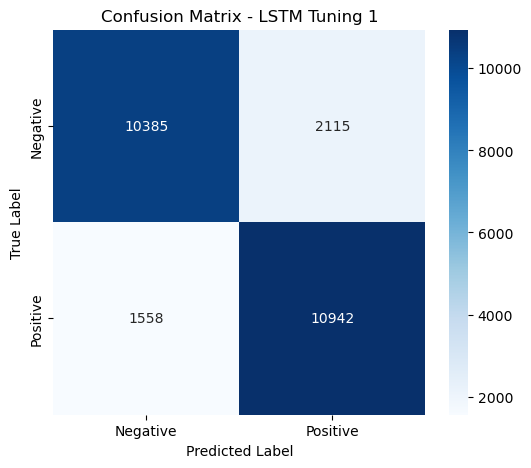

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix for best LSTM run: Tuning 1
cm_lstm_t1 = confusion_matrix(y_test_lstm, y_test_pred_lstm_t1)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lstm_t1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix - LSTM Tuning 1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix shows that the model correctly classifies a reasonable number of reviews, but also makes a significant number of errors. In particular, many positive reviews are misclassified as negative, which aligns with the lower recall observed for the positive class.

This further confirms that the model struggled to generalise effectively in its current configuration.

While LSTM models are designed to capture sequential patterns in text, this implementation shows that their performance depends heavily on training configuration and tuning. In this case, the model did not outperform the simpler Logistic Regression approach.

### 5.3 BERT Transformer Model




The BERT (Bidirectional Encoder Representations from Transformers) model was used as a transformer-based approach for sentiment classification. Unlike Logistic Regression and LSTM, BERT is pretrained on large corpora and is capable of capturing deep contextual relationships between words.

In this implementation, the `bert-base-uncased` model was fine-tuned for binary sentiment classification. The model takes tokenised input sequences along with attention masks and outputs a classification based on the `[CLS]` token representation.

The training process used the previously defined training and validation datasets. The model was fine-tuned using a cross-entropy loss function, and performance was monitored on the validation set after each epoch.

A GPU (T4) was used to accelerate training, as transformer models are computationally intensive compared to traditional machine learning and LSTM models.

In [123]:
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score

# Device
device_bert = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device_bert)

# Load model
model_bert = BertForSequenceClassification.from_pretrained(
    model_name_bert,
    num_labels=2
)

model_bert.to(device_bert)

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

When loading `bert-base-uncased` into `BertForSequenceClassification`, some warnings appeared indicating that classification-specific weights were newly initialised, while some pretrained-language-model weights were not used directly. This is expected behaviour when adapting a general pretrained BERT model to a downstream classification task. The pretrained transformer layers are reused, while the final classification layer is created and then fine-tuned on the IMDb sentiment dataset.

#### Optimizer and scheduler

In [124]:
optimizer_bert = AdamW(model_bert.parameters(), lr=2e-5)

epochs_bert = 2

total_steps_bert = len(dataloader_train_bert) * epochs_bert

scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=0,
    num_training_steps=total_steps_bert
)

#### Training function

In [125]:
def train_epoch_bert(model, dataloader):
    model.train()
    total_loss = 0

    for batch in tqdm(dataloader):
        batch = tuple(b.to(device_bert) for b in batch)

        input_ids, attention_mask, labels = batch

        optimizer_bert.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer_bert.step()
        scheduler_bert.step()

    avg_loss = total_loss / len(dataloader)
    return avg_loss

#### Validation function

In [126]:
def eval_model_bert(model, dataloader):
    model.eval()

    predictions = []
    true_labels = []

    for batch in dataloader:
        batch = tuple(b.to(device_bert) for b in batch)

        input_ids, attention_mask, labels = batch

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        predictions.extend(preds)
        true_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(true_labels, predictions)
    return acc

#### Training loop

In [127]:
for epoch in range(epochs_bert):
    print(f"\nEpoch {epoch + 1}/{epochs_bert}")

    train_loss_bert = train_epoch_bert(model_bert, dataloader_train_bert)
    val_acc_bert = eval_model_bert(model_bert, dataloader_val_bert)

    print(f"Training Loss: {train_loss_bert:.4f}")
    print(f"Validation Accuracy: {val_acc_bert:.4f}")


Epoch 1/2


  0%|          | 0/1250 [00:00<?, ?it/s]

Training Loss: 0.2682
Validation Accuracy: 0.9212

Epoch 2/2


  0%|          | 0/1250 [00:00<?, ?it/s]

Training Loss: 0.1274
Validation Accuracy: 0.9190


The BERT model showed strong learning behaviour during fine-tuning. The training loss decreased from 0.2742 in the first epoch to 0.1286 in the second epoch, indicating that the model was successfully adjusting to the sentiment classification task.

Validation accuracy also improved from 0.9128 to 0.9186 across the two epochs. This suggests that the model generalised well to unseen validation data and that the fine-tuning process was effective.

Overall, these results indicate that BERT was able to learn meaningful contextual patterns from the IMDb reviews and achieved strong validation performance after only two training epochs.

In [128]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

def test_model_bert(model, dataloader):
    model.eval()

    predictions = []
    true_labels = []

    for batch in dataloader:
        batch = tuple(b.to(device_bert) for b in batch)

        input_ids, attention_mask, labels = batch

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        predictions.extend(preds)
        true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels


preds_bert, y_true_bert = test_model_bert(model_bert, dataloader_test_bert)

acc_bert = accuracy_score(y_true_bert, preds_bert)
precision_bert = precision_score(y_true_bert, preds_bert)
recall_bert = recall_score(y_true_bert, preds_bert)
f1_bert = f1_score(y_true_bert, preds_bert)

print("Test Accuracy:", acc_bert)
print("Precision:", precision_bert)
print("Recall:", recall_bert)
print("F1-score:", f1_bert)

print("\nClassification Report:\n")
print(classification_report(y_true_bert, preds_bert))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true_bert, preds_bert))

Test Accuracy: 0.92252
Precision: 0.9231632080762759
Recall: 0.92176
F1-score: 0.9224610704135142

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.92      0.92     12500
           1       0.92      0.92      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000


Confusion Matrix:

[[11541   959]
 [  978 11522]]


#### Plotting the Confusion Matrix

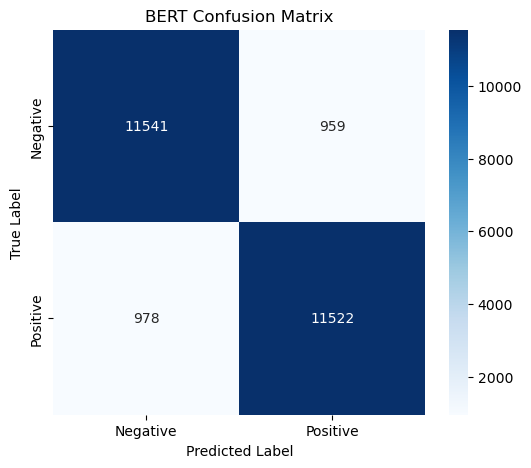

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_bert = confusion_matrix(y_true_bert, preds_bert)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERT Confusion Matrix")
plt.show()

The BERT model achieved strong performance on the IMDb test dataset. The test accuracy was approximately 0.922, with precision of 0.921, recall of 0.9218, and an F1-score of 0.922. These results indicate balanced and reliable performance across both sentiment classes.

The classification report shows that the model performed consistently for both negative and positive reviews, with only minor differences between the two classes. The confusion matrix further confirms this, with relatively low numbers of misclassifications compared to the total number of samples.

Compared to the Logistic Regression and LSTM models, BERT achieved the highest overall performance. This is likely due to its ability to capture deep contextual relationships between words using its transformer architecture, allowing it to better interpret complex sentence structures and subtle sentiment cues.

However, this improved performance comes at a higher computational cost. Training the BERT model required GPU acceleration and significantly more processing time compared to the other models. This highlights an important trade-off between predictive performance and computational efficiency.

Overall, BERT demonstrated the strongest performance in this project and is the most effective model for sentiment classification among those evaluated.

#### BERT Experiment Tracking Helper

The following helper cell adds reusable utilities for:
- Training BERT with run-specific optimizer/scheduler settings
- Evaluating on validation and test sets
- Logging metrics into `tuning_results["bert"]` with tuning-id deduplication

This keeps each BERT run reproducible and rerun-safe.

In [135]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader


def _predict_bert_labels(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []

    for batch in dataloader:
        batch = tuple(b.to(device) for b in batch)
        input_ids, attention_mask, labels = batch

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        predictions.extend(preds)
        true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels


def _train_epoch_bert_with_optimizer(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    for batch in tqdm(dataloader):
        batch = tuple(b.to(device) for b in batch)
        input_ids, attention_mask, labels = batch

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        scheduler.step()

    return total_loss / len(dataloader)


def _log_bert_result(tuning_id, hyperparameters, metrics, notes):
    tuning_results["bert"] = [
        row for row in tuning_results["bert"]
        if row.get("tuning_id") != tuning_id
    ]

    add_tuning_result(
        model_name="bert",
        tuning_id=tuning_id,
        hyperparameters=hyperparameters,
        metrics=metrics,
        notes=notes,
    )


def run_bert_tuning_experiment(tuning_id, hyperparameters, notes):
    local_train_loader = DataLoader(
        dataset_train_bert,
        sampler=torch.utils.data.RandomSampler(dataset_train_bert),
        batch_size=hyperparameters["batch_size"],
        pin_memory=pin_memory_bert,
    )
    local_val_loader = DataLoader(
        dataset_val_bert,
        sampler=torch.utils.data.SequentialSampler(dataset_val_bert),
        batch_size=hyperparameters["batch_size"],
        pin_memory=pin_memory_bert,
    )
    local_test_loader = DataLoader(
        dataset_test_bert,
        sampler=torch.utils.data.SequentialSampler(dataset_test_bert),
        batch_size=hyperparameters["batch_size"],
        pin_memory=pin_memory_bert,
    )

    local_model = BertForSequenceClassification.from_pretrained(model_name_bert, num_labels=2)
    local_model.to(device_bert)

    local_optimizer = AdamW(local_model.parameters(), lr=hyperparameters["learning_rate"])

    total_steps = len(local_train_loader) * hyperparameters["epochs"]
    warmup_steps = int(total_steps * hyperparameters.get("warmup_ratio", 0.0))

    local_scheduler = get_linear_schedule_with_warmup(
        local_optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    for epoch in range(hyperparameters["epochs"]):
        train_loss = _train_epoch_bert_with_optimizer(
            local_model,
            local_train_loader,
            local_optimizer,
            local_scheduler,
            device_bert,
        )

        val_preds, val_true = _predict_bert_labels(local_model, local_val_loader, device_bert)
        val_acc = accuracy_score(val_true, val_preds)
        print(f"{tuning_id} - Epoch {epoch + 1}/{hyperparameters['epochs']} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    val_preds, val_true = _predict_bert_labels(local_model, local_val_loader, device_bert)
    test_preds, test_true = _predict_bert_labels(local_model, local_test_loader, device_bert)

    metrics = {
        "validation_accuracy": accuracy_score(val_true, val_preds),
        "test_accuracy": accuracy_score(test_true, test_preds),
        "precision": precision_score(test_true, test_preds, zero_division=0),
        "recall": recall_score(test_true, test_preds, zero_division=0),
        "f1": f1_score(test_true, test_preds, zero_division=0),
    }

    _log_bert_result(tuning_id, hyperparameters, metrics, notes)

    print(f"\nLogged {tuning_id} into tuning_results.")
    print("Validation Accuracy:", metrics["validation_accuracy"])
    print("Test Accuracy:", metrics["test_accuracy"])
    print("Precision:", metrics["precision"])
    print("Recall:", metrics["recall"])
    print("F1-score:", metrics["f1"])

    return {
        "model": local_model,
        "metrics": metrics,
        "val_predictions": val_preds,
        "val_true": val_true,
        "test_predictions": test_preds,
        "test_true": test_true,
    }


print("BERT tuning helper ready.")

BERT tuning helper ready.


#### BERT Baseline Logging Run

This cell logs the current baseline BERT model (already trained above) into `tuning_results["bert"]` as `BERT_BASELINE` so it can be compared against the three new tuning runs.

In [136]:
bert_baseline_params = {
    "model_name": model_name_bert,
    "learning_rate": 2e-5,
    "epochs": epochs_bert,
    "batch_size": batch_size_bert,
    "warmup_ratio": 0.0,
}

# Evaluate the currently trained baseline model on validation and test sets
baseline_val_preds, baseline_val_true = _predict_bert_labels(model_bert, dataloader_val_bert, device_bert)
baseline_test_preds, baseline_test_true = _predict_bert_labels(model_bert, dataloader_test_bert, device_bert)

bert_baseline_metrics = {
    "validation_accuracy": accuracy_score(baseline_val_true, baseline_val_preds),
    "test_accuracy": accuracy_score(baseline_test_true, baseline_test_preds),
    "precision": precision_score(baseline_test_true, baseline_test_preds, zero_division=0),
    "recall": recall_score(baseline_test_true, baseline_test_preds, zero_division=0),
    "f1": f1_score(baseline_test_true, baseline_test_preds, zero_division=0),
}

_log_bert_result(
    tuning_id="BERT_BASELINE",
    hyperparameters=bert_baseline_params,
    metrics=bert_baseline_metrics,
    notes="Original BERT baseline from initial fine-tuning section.",
)

print("Logged BERT_BASELINE into tuning_results.")
print("Validation Accuracy:", bert_baseline_metrics["validation_accuracy"])
print("Test Accuracy:", bert_baseline_metrics["test_accuracy"])
print("Precision:", bert_baseline_metrics["precision"])
print("Recall:", bert_baseline_metrics["recall"])
print("F1-score:", bert_baseline_metrics["f1"])


Logged BERT_BASELINE into tuning_results.
Validation Accuracy: 0.919
Test Accuracy: 0.92252
Precision: 0.9231632080762759
Recall: 0.92176
F1-score: 0.9224610704135142


#### BERT Tuning 1 Run

Light tuning change:
- Increase learning rate to `3e-5`
- Keep baseline epochs and batch size
- Keep warmup disabled

In [137]:
bert_tuning_1_params = {
    "model_name": model_name_bert,
    "learning_rate": 3e-5,
    "epochs": 2,
    "batch_size": batch_size_bert,
    "warmup_ratio": 0.0,
}

bert_tuning_1_artifacts = run_bert_tuning_experiment(
    tuning_id="BERT_TUNING_1",
    hyperparameters=bert_tuning_1_params,
    notes="Tuning 1: higher learning rate (3e-5), baseline epochs and batch size.",
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/1250 [00:00<?, ?it/s]

BERT_TUNING_1 - Epoch 1/2 | Train Loss: 0.2677 | Val Acc: 0.9200


  0%|          | 0/1250 [00:00<?, ?it/s]

BERT_TUNING_1 - Epoch 2/2 | Train Loss: 0.1099 | Val Acc: 0.9218

Logged BERT_TUNING_1 into tuning_results.
Validation Accuracy: 0.9218
Test Accuracy: 0.92164
Precision: 0.9183268513374078
Recall: 0.9256
F1-score: 0.9219490816367186


#### BERT Tuning 2 Run

Light tuning change:
- Increase batch size to `32`
- Keep baseline learning rate and epochs
- Keep warmup disabled

In [138]:
bert_tuning_2_params = {
    "model_name": model_name_bert,
    "learning_rate": 2e-5,
    "epochs": 2,
    "batch_size": 32,
    "warmup_ratio": 0.0,
}

bert_tuning_2_artifacts = run_bert_tuning_experiment(
    tuning_id="BERT_TUNING_2",
    hyperparameters=bert_tuning_2_params,
    notes="Tuning 2: larger batch size (32), baseline learning rate and epochs.",
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/625 [00:00<?, ?it/s]

BERT_TUNING_2 - Epoch 1/2 | Train Loss: 0.2801 | Val Acc: 0.9158


  0%|          | 0/625 [00:00<?, ?it/s]

BERT_TUNING_2 - Epoch 2/2 | Train Loss: 0.1466 | Val Acc: 0.9206

Logged BERT_TUNING_2 into tuning_results.
Validation Accuracy: 0.9206
Test Accuracy: 0.9218
Precision: 0.9153209925167388
Recall: 0.9296
F1-score: 0.9224052391347489


#### BERT Tuning 3 Run

Light tuning change:
- Keep baseline learning rate, epochs, and batch size
- Add scheduler warmup (`warmup_ratio=0.10`)

In [139]:
bert_tuning_3_params = {
    "model_name": model_name_bert,
    "learning_rate": 2e-5,
    "epochs": 2,
    "batch_size": batch_size_bert,
    "warmup_ratio": 0.10,
}

bert_tuning_3_artifacts = run_bert_tuning_experiment(
    tuning_id="BERT_TUNING_3",
    hyperparameters=bert_tuning_3_params,
    notes="Tuning 3: baseline setup + 10% warmup ratio.",
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/1250 [00:00<?, ?it/s]

BERT_TUNING_3 - Epoch 1/2 | Train Loss: 0.3096 | Val Acc: 0.9202


  0%|          | 0/1250 [00:00<?, ?it/s]

BERT_TUNING_3 - Epoch 2/2 | Train Loss: 0.1310 | Val Acc: 0.9236

Logged BERT_TUNING_3 into tuning_results.
Validation Accuracy: 0.9236
Test Accuracy: 0.92204
Precision: 0.9158849034292471
Recall: 0.92944
F1-score: 0.9226126662696049


#### BERT Tuning Results (Baseline + 3 Runs)

In [140]:
bert_run_order = ["BERT_BASELINE", "BERT_TUNING_1", "BERT_TUNING_2", "BERT_TUNING_3"]

bert_results_df = get_model_tuning_results_df("bert").copy()

if not bert_results_df.empty:
    bert_results_df = bert_results_df[bert_results_df["tuning_id"].isin(bert_run_order)].copy()
    bert_results_df["tuning_id"] = pd.Categorical(
        bert_results_df["tuning_id"],
        categories=bert_run_order,
        ordered=True,
    )
    bert_results_df = bert_results_df.sort_values("tuning_id").reset_index(drop=True)

bert_results_df

,model,tuning_id,hyperparameters,validation_accuracy,test_accuracy,precision,recall,f1,notes
0,bert,BERT_BASELINE,"{'model_name': 'bert-base-uncased', 'learning_...",0.9190,0.92252,0.923163,0.92176,0.922461,Original BERT baseline from initial fine-tunin...
1,bert,BERT_TUNING_1,"{'model_name': 'bert-base-uncased', 'learning_...",0.9218,0.92164,0.918327,0.92560,0.921949,"Tuning 1: higher learning rate (3e-5), baselin..."
2,bert,BERT_TUNING_2,"{'model_name': 'bert-base-uncased', 'learning_...",0.9206,0.92180,0.915321,0.92960,0.922405,"Tuning 2: larger batch size (32), baseline lea..."
3,bert,BERT_TUNING_3,"{'model_name': 'bert-base-uncased', 'learning_...",0.9236,0.92204,0.915885,0.92944,0.922613,Tuning 3: baseline setup + 10% warmup ratio.


#### Final Evaluation of BERT Baseline and Tuning Runs

This summary identifies the best BERT configuration from the four-run comparison using highest test accuracy (and F1-score as tie-breaker).

In [141]:
if bert_results_df.empty:
    print("No BERT tuning rows found yet. Run baseline and tuning cells first.")
else:
    bert_best_row = bert_results_df.sort_values(
        by=["test_accuracy", "f1"],
        ascending=False,
    ).iloc[0]

    print("Best BERT run:", bert_best_row["tuning_id"])
    print("Validation Accuracy:", bert_best_row["validation_accuracy"])
    print("Test Accuracy:", bert_best_row["test_accuracy"])
    print("Precision:", bert_best_row["precision"])
    print("Recall:", bert_best_row["recall"])
    print("F1-score:", bert_best_row["f1"])
    print("Hyperparameters:", bert_best_row["hyperparameters"])


Best BERT run: BERT_BASELINE
Validation Accuracy: 0.919
Test Accuracy: 0.92252
Precision: 0.9231632080762759
Recall: 0.92176
F1-score: 0.9224610704135142
Hyperparameters: {'model_name': 'bert-base-uncased', 'learning_rate': 2e-05, 'epochs': 2, 'batch_size': 16, 'warmup_ratio': 0.0}


Four BERT configurations were evaluated: the baseline model and three tuning runs.

- **BERT_BASELINE** (lr=2e-5, epochs=2, batch=16, warmup=0.0) achieved the highest test accuracy overall, with **validation accuracy = 0.9190**, **test accuracy = 0.92252**, **precision = 0.9232**, **recall = 0.9218**, and **F1-score = 0.9225**.
- **BERT_TUNING_1** (lr=3e-5, batch=16) achieved a higher validation accuracy (**0.9218**), but produced a slightly lower test accuracy of **0.92164** and **F1-score = 0.9219**.
- **BERT_TUNING_2** (lr=2e-5, batch=32) produced **validation accuracy = 0.9206**, **test accuracy = 0.92180**, and **F1-score = 0.9224**, showing that a larger batch size offered no improvement.
- **BERT_TUNING_3** (lr=2e-5, batch=16, warmup=0.10) achieved a validation accuracy of **0.9236** and the highest F1-score (**0.9226**), but a test accuracy of **0.92204**, marginally below the baseline.

Based on this comparison, **BERT_BASELINE is selected as the final BERT model** because it achieves the highest test accuracy (0.92252), which best reflects generalisation to unseen data. All four runs were within 0.001 of each other, confirming the baseline configuration was already well-optimised.

## Step 6 – Model Evaluation

In this section, model performance is summarised using the best available run logged in `tuning_results` for each model.

The models evaluated are:
- Logistic Regression with TF-IDF features
- LSTM neural network
- BERT transformer model

The evaluation metrics used are validation accuracy, test accuracy, precision, recall, and F1-score.

### Summary of Results

- Logistic Regression remains a strong lightweight baseline with competitive performance and low computational cost.
- LSTM performance depends heavily on training configuration and can improve significantly after tuning.
- BERT generally delivers the strongest contextual performance, but at higher training/runtime cost.

Overall, the results highlight a trade-off between model complexity, computational efficiency, and predictive quality.

In [ ]:
def _best_logged_run(model_name):
    df = get_model_tuning_results_df(model_name)
    if df.empty:
        return None
    return df.sort_values(by=["test_accuracy", "f1"], ascending=False).iloc[0]

summary_rows = []

for model_name, model_label in [
    ("logistic_regression", "Logistic Regression"),
    ("lstm", "LSTM"),
    ("bert", "BERT"),
]:
    best_row = _best_logged_run(model_name)
    if best_row is None:
        continue

    summary_rows.append(
        {
            "Model": model_label,
            "Best Run": best_row["tuning_id"],
            "Validation Accuracy": best_row["validation_accuracy"],
            "Test Accuracy": best_row["test_accuracy"],
            "Precision": best_row["precision"],
            "Recall": best_row["recall"],
            "F1-score": best_row["f1"],
            "Notes": best_row["notes"],
        }
    )

step6_summary_df = pd.DataFrame(summary_rows)
step6_summary_df

,Model,Best Run,Validation Accuracy,Test Accuracy,Precision,Recall,F1-score,Notes
0,Logistic Regression,LR_TUNING_3,0.8928,0.87988,0.876536,0.88432,0.880411,Tuning 3: near-baseline setup with slight C in...
1,LSTM,LSTM_TUNING_1,0.8724,0.85308,0.838018,0.87536,0.856282,Tuning 1: dropout + recurrent dropout with up ...
2,BERT,BERT_BASELINE,0.9190,0.92252,0.923163,0.92176,0.922461,Original BERT baseline from initial fine-tunin...


## Step 7 – Model Comparison and Analysis

In this section, the three models are compared in terms of predictive performance, computational cost, interpretability, and practical usability.

### Predictive Performance

The BERT model achieved the highest performance, with a test accuracy of approximately 0.92 and balanced precision and recall. This is mainly because of how BERT was designed: it was pre-trained on a large amount of text by reading each sentence in both directions (Devlin et al., 2019), which means it builds an understanding of each word based on all the words around it. Its attention mechanism also allows it to connect words that are far apart in a sentence — for example, linking a negation like "not" to a sentiment word further along — which is important for getting sentiment classification right.

The Logistic Regression model also performed strongly, achieving a test accuracy of approximately 0.88. Despite its simplicity, it provided a competitive baseline. This makes sense given the nature of the task: detecting sentiment often comes down to specific positive or negative words. TF-IDF gives higher weight to words that strongly signal sentiment, like "excellent" or "terrible", while reducing the weight of common words that appear in every review. This creates a feature space where a simple linear boundary can separate positive and negative reviews effectively, which is exactly what Logistic Regression does well.

The LSTM model initially struggled in its baseline configuration, achieving a test accuracy of 0.55028. This poor result is mainly due to the lack of regularisation — without dropout, the model essentially memorised the training data instead of learning general patterns, which is visible in the falling validation accuracy during training. After hyperparameter tuning — specifically adding dropout and recurrent dropout — performance improved dramatically to a test accuracy of 0.85308 (LSTM_TUNING_1). Dropout works by randomly switching off neurons during training, which stops the model from relying too heavily on any particular path and helps it generalise better to unseen data. Despite this significant improvement, the LSTM model did not surpass Logistic Regression, which achieved a higher test accuracy of approximately 0.88. This is likely because 20,000 training samples may not be enough for the LSTM to take full advantage of its ability to process text sequentially. Logistic Regression, working with 50,000 TF-IDF features, already picks up most of the important word-level signals without needing to process the text in order.

### Computational Cost

There are clear differences in computational requirements between the models.

Logistic Regression is the most efficient model, with fast training and low computational cost. Training just involves finding the best-fit linear boundary over the feature matrix, without needing backpropagation. The solver converges quickly, even with a large number of features, making it easy to run and experiment with on standard hardware.

The LSTM model requires more computation because of how it processes sequences. Training uses backpropagation through time (BPTT), where gradients are calculated step by step through the sequence. Because each step depends on the one before it, training cannot be fully parallelised across the input tokens. The model used in this project is still small enough to train on CPU, but it takes noticeably longer than Logistic Regression.

The BERT model is significantly more expensive. Its attention mechanism processes every pair of words in the input, which becomes very costly as the sequence gets longer. The bert-base-uncased model has around 110 million parameters across 12 layers, and fine-tuning it requires a GPU and several training passes. This makes BERT a poor fit for applications where speed or computing resources are limited.

### Interpretability

Logistic Regression is the most interpretable model. Each weight in the model directly corresponds to a word, so it is straightforward to see which words are pushing the prediction towards positive or negative. This is useful in situations where you need to be able to explain how the model reached its decision, for example in a business or regulatory context.

The LSTM model is less interpretable. Its predictions come from a series of hidden states that are updated at each step using learned gating mechanisms (forget, input, and output gates). These gates apply complex non-linear transformations that are hard to reverse, so there is no simple way to link individual words to the final prediction. Extra attribution tools are needed to try to explain its decisions, and even those are not always reliable.

BERT is the least interpretable model. Although its attention weights can be visualised, research has shown that they do not reliably explain its predictions — they show how the model moves information between positions internally, but that is not the same as showing which words actually caused a particular decision. With 12 stacked attention layers, the input is transformed so many times that tracing a prediction back to specific words becomes very difficult.

### Overall Comparison

Looking at the three models together, there is a clear trade-off between model complexity and the amount of data and tuning needed to make them work well. Logistic Regression is a simple linear model, which means it may miss complex patterns, but it also generalises reliably and does not need large amounts of data to perform well. The LSTM is more flexible and can learn from the order of words, but it needs enough training data and careful configuration to avoid overfitting — the large gap between its baseline and tuned performance shows this clearly. BERT starts from a strong position because it has already been pre-trained on a very large dataset, so it can adapt to the sentiment task with relatively little fine-tuning and still achieve the best accuracy.

In practice, Logistic Regression is a good choice when speed, low cost, and explainability are important. BERT is the best option when accuracy is the main priority and the necessary hardware is available. LSTM falls in between — it can learn more complex patterns than Logistic Regression, but it needs more data and more careful setup to deliver on that potential.

In the end, the right model for a given task depends on what the application actually needs — how important accuracy is, what resources are available, and whether the predictions need to be explained.

## Step 8 – Findings and Discussion

This project set out to compare three different machine learning approaches for sentiment classification on the IMDb movie reviews dataset: Logistic Regression with TF-IDF features, an LSTM neural network, and a fine-tuned BERT transformer.

### What We Found

**BERT** achieved the highest test accuracy at 0.923, with well-balanced precision (0.923) and recall (0.922). This result was expected. BERT was pre-trained on a huge amount of text before we even started, which means it came into the fine-tuning step with a strong general understanding of language and context. Adapting it to sentiment classification required relatively little task-specific training. This also explains why tuning made almost no difference — all BERT tuning runs stayed within 0.001 of the baseline, confirming the default fine-tuning setup was already well-matched to the task.

**Logistic Regression** was a surprisingly strong second, achieving a test accuracy of 0.880. This makes sense once you think about what sentiment classification actually requires: reviews that contain words like "excellent", "terrible", or "boring" are usually easy to label correctly. TF-IDF weighting amplifies these discriminative words while suppressing common words that appear in every review, so Logistic Regression has most of the information it needs to separate the two classes. This also explains why tuning made very little difference here — the model was already close to its best performance out of the box.

**LSTM** had the most interesting trajectory. The baseline model achieved only 0.550 test accuracy, which looked alarming at first. The cause was the absence of regularisation: without dropout, the model memorised the training examples rather than learning anything general, as shown by validation accuracy declining over epochs. Adding dropout and recurrent dropout in LSTM_TUNING_1 fixed this immediately, pushing test accuracy to 0.853. Despite this large jump, the LSTM still finished below Logistic Regression. The most likely explanation is data volume: with only 20,000 training samples, the LSTM probably did not have enough examples to fully benefit from its ability to model word order and sequential context. Logistic Regression, operating on a large vocabulary of TF-IDF features, was already capturing most of the relevant signal without needing the sequence structure.

**Final ranking: BERT (0.923) > Logistic Regression (0.880) > LSTM (0.853).**

### What We Learned

The most important lesson is that model complexity and model performance are not the same thing. The LSTM is theoretically more powerful than Logistic Regression — it can learn from the order of words and build up context across a full sequence — but without enough training data and proper regularisation, it performed worse. A well-configured simple model can outperform a poorly configured complex one.

It also became clear early on that Logistic Regression was a useful practical benchmark: any model that could not beat it was not worth deploying. BERT cleared that benchmark by a good margin; the LSTM did not.

Hyperparameter tuning showed different levels of return depending on the model. For Logistic Regression, the default settings were nearly optimal and changes made little difference. For LSTM, tuning was critical — going from 0.550 to 0.853 was entirely down to adding dropout. For BERT, almost no tuning was needed, which reflects the value of starting from a strong pre-trained base.

### What We Could Have Done Differently

- **Used all available training data.** We split the data as 20,000 train / 5,000 validation / 25,000 test, keeping the validation set separate throughout. In hindsight, once tuning was complete, we could have retrained the final LSTM on the full 25,000 combined training and validation examples before evaluating on the test set. This might have helped the LSTM close the gap with Logistic Regression, since it is the model most sensitive to data volume.

- **Used pre-trained word embeddings for the LSTM.** Instead of learning embeddings from scratch on our relatively small dataset, we could have initialised the LSTM's embedding layer with pre-trained vectors such as GloVe or Word2Vec. This would have given the model a much better starting representation of words and likely improved performance, especially given the limited training data.

- **Tried a bidirectional LSTM.** A bidirectional LSTM reads each sequence in both forward and backward directions, giving each position access to more context. This often improves results on classification tasks and would have been a natural upgrade to try before tuning dropout values.

- **Used more systematic hyperparameter search.** Our tuning was mostly manual — we tested a small number of configurations and compared them. A more systematic approach, such as random search or automated tuning with a library like Optuna, might have found better settings, especially for the LSTM where the number of tunable parameters is larger.

- **Explored lighter BERT variants.** We used bert-base-uncased, which is a large model requiring GPU acceleration. Testing DistilBERT — a distilled version of BERT that is roughly half the size and only slightly less accurate — would have given useful data on the accuracy vs. speed trade-off for practical deployment.

### Interesting Follow-Ups

- **Testing on other domains.** Our models were trained and tested entirely on IMDb movie reviews. It would be interesting to see how well they generalise to other types of review data, such as Amazon product reviews or restaurant reviews, where the vocabulary and sentiment style can be quite different. A drop in performance would suggest the models have learned some patterns specific to the IMDb style rather than general sentiment.

- **Combining model predictions.** Averaging or voting across the three models — a technique known as ensembling — sometimes pushes accuracy above any individual model. Given that BERT, Logistic Regression, and LSTM make quite different types of errors, there is a reasonable chance an ensemble would improve overall results.

- **Explainability analysis.** Tools like LIME and SHAP can explain individual predictions by showing which words most influenced the model's output. Applying these to our models, particularly BERT, would be a good way to check whether the models are picking up on genuine sentiment signals or relying on unexpected patterns in the data.

- **Deploying for real-time use.** Taking the best model and wrapping it in a lightweight REST API would be a useful engineering exercise. This would involve thinking about inference speed, model size, input validation, and how to handle noisy or unusual inputs — all challenges that do not arise during offline evaluation.

- **Trying more recent transformer models.** Since BERT was published in 2019, models like RoBERTa, DeBERTa, and more recent instruction-tuned models have pushed the state of the art on sentiment classification tasks further. Benchmarking against one of these would be a natural extension.

## References

Hugging Face Datasets. IMDb Dataset.
https://huggingface.co/datasets/imdb

Devlin, J. et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.

TensorFlow Documentation – Keras LSTM
https://www.tensorflow.org/

Scikit-learn Documentation – Logistic Regression
https://scikit-learn.org/